# 1. Setup și Instalări
Ne asigurăm că avem toate bibliotecile necesare instalate, inclusiv `timm` pentru Inception-ResNet-v2.

In [10]:
# Rulează asta o singură dată
# !pip install timm pandas matplotlib seaborn scikit-learn tqdm

In [11]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kushagratandon12/diabetic-retinopathy-balanced")

# print("Path to dataset files:", path)

# 2. Explorarea Datelor (EDA)
Verificăm dacă DataLoader-ul nostru încarcă corect imaginile și dacă augmentările (rotații, culori) arată bine pe setul de antrenare.

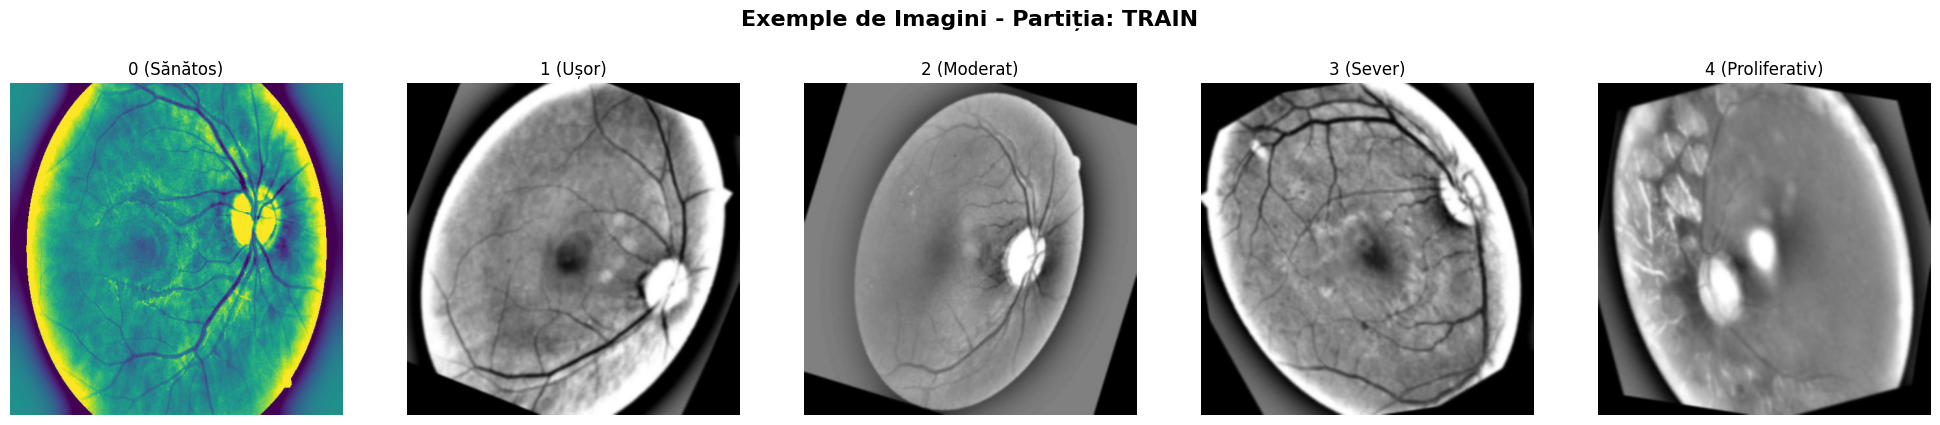

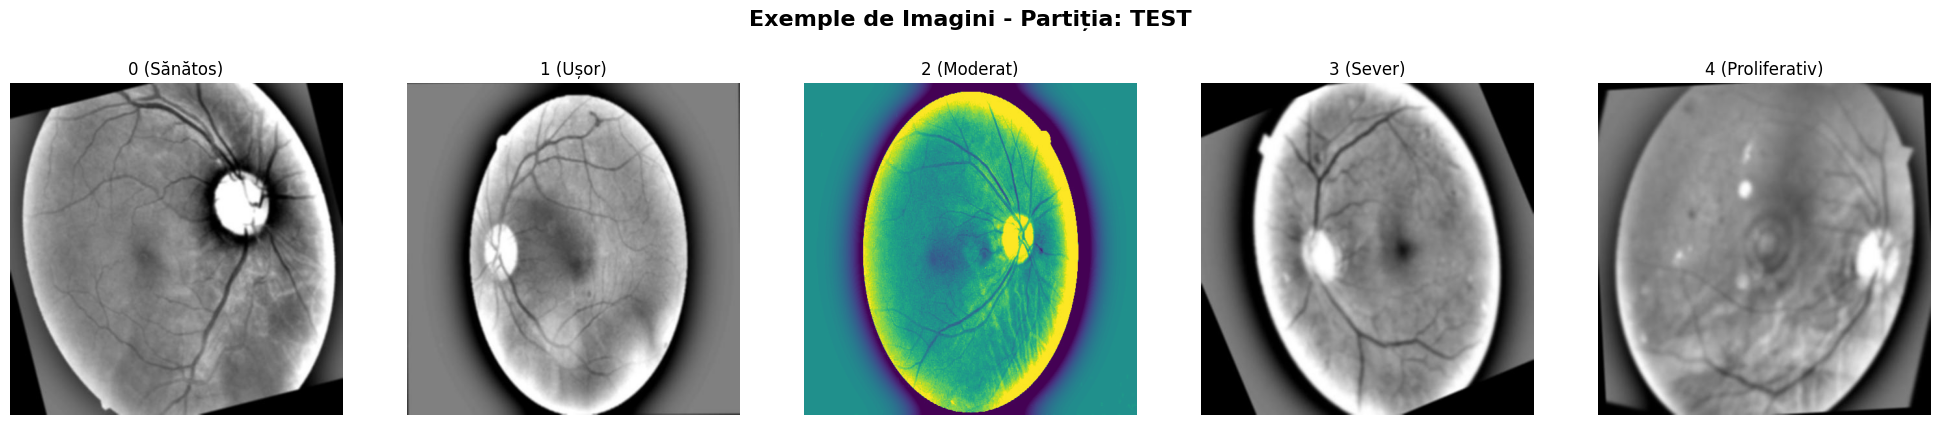

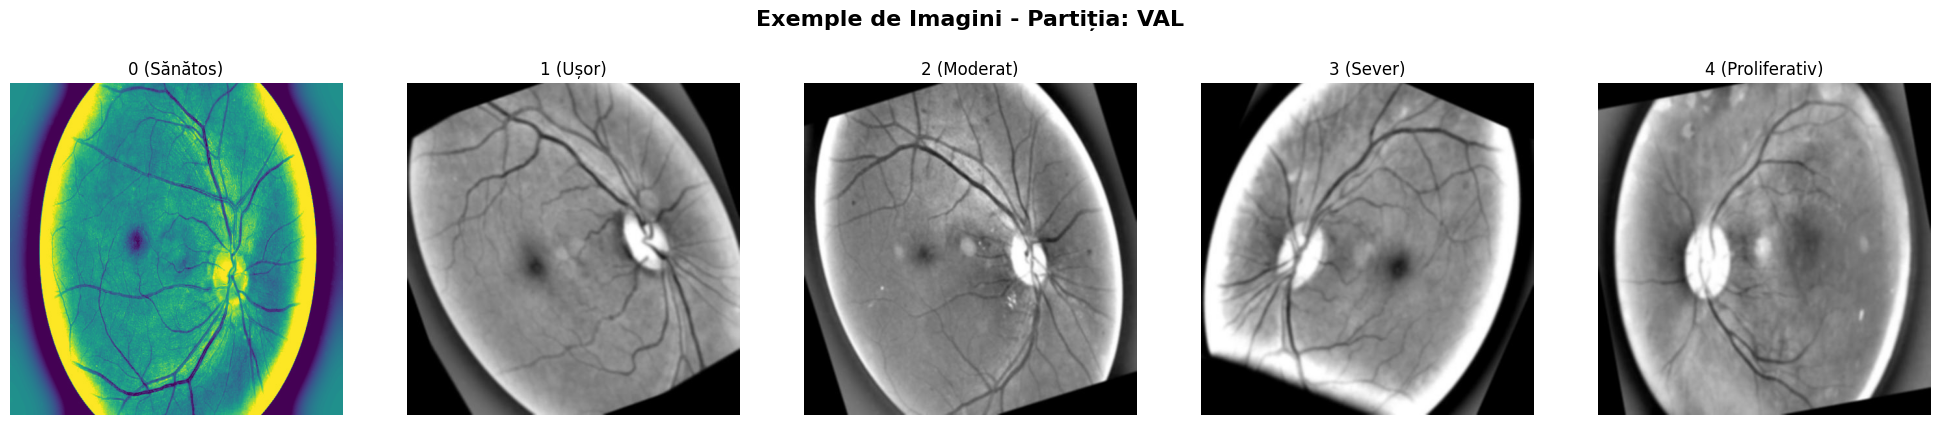

In [14]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def vizualizeaza_toate_partitiile(baza_dir=r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data'):
    """
    Parcurge folderele train, test și val și afișează o imagine din fiecare clasă.
    """
    partitii = ['train', 'test', 'val']
    clase = ['0', '1', '2', '3', '4']
    nume_clase = ['0 (Sănătos)', '1 (Ușor)', '2 (Moderat)', '3 (Sever)', '4 (Proliferativ)']

    for partitie in partitii:
        folder_partitie = os.path.join(baza_dir, partitie)
        
        # Dacă folderul partiției nu există, îl sărim
        if not os.path.exists(folder_partitie):
            print(f"⚠️ Partiția '{partitie}' nu există în folderul principal. Sărim peste.")
            continue

        # Creăm o fereastră nouă pentru fiecare partiție
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f'Exemple de Imagini - Partiția: {partitie.upper()}', fontsize=16, fontweight='bold', y=1.05)

        for i, clasa in enumerate(clase):
            folder_clasa = os.path.join(folder_partitie, clasa)
            
            # Verificăm dacă folderul clasei există
            if not os.path.exists(folder_clasa):
                axes[i].text(0.5, 0.5, 'Folder Lipsă', ha='center', va='center')
                axes[i].axis('off')
                axes[i].set_title(nume_clase[i])
                continue
                
            imagini = [f for f in os.listdir(folder_clasa) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            if not imagini:
                axes[i].text(0.5, 0.5, 'Fără Imagini', ha='center', va='center')
                axes[i].axis('off')
                axes[i].set_title(nume_clase[i])
                continue

            # Alegem o imagine random și o afișăm
            imagine_aleasa = random.choice(imagini)
            cale_imagine = os.path.join(folder_clasa, imagine_aleasa)
            
            try:
                img = Image.open(cale_imagine)
                axes[i].imshow(img)
                axes[i].set_title(nume_clase[i], fontsize=12)
            except Exception as e:
                axes[i].text(0.5, 0.5, 'Eroare Citire', ha='center', va='center')
            
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

# Apelăm funcția
vizualizeaza_toate_partitiile()

# Experimente Diabetic_Balanced_Data + APTOS
APTOS este citit direct din `datasets/aptos/aptos_ben_graham`, unde imaginile sunt deja prelucrate Ben Graham si deja augmentate. Fiecare experiment salveaza modelul si graficele cu numele combinatiei train/test.

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: balanced_aptos_to_balanced_aptos | TRAIN/VAL=combined | TEST=combined
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=42292 | VALIDARE=10940 | TESTARE=6221


Ep 01/15 | T_Loss: 0.6095 | V_Loss: 0.5171 | V_Acc: 59.2% | V_AUC: 0.8974 NOU BEST
Durata epoca: 6.26 min


Ep 02/15 | T_Loss: 0.4732 | V_Loss: 0.4554 | V_Acc: 65.3% | V_AUC: 0.9079 NOU BEST
Durata epoca: 6.49 min


Ep 03/15 | T_Loss: 0.4076 | V_Loss: 0.4139 | V_Acc: 68.2% | V_AUC: 0.9191 NOU BEST
Durata epoca: 6.80 min


Ep 04/15 | T_Loss: 0.3583 | V_Loss: 0.3919 | V_Acc: 69.7% | V_AUC: 0.9277 NOU BEST
Durata epoca: 7.00 min


...

Ep 12/15 | T_Loss: 0.1800 | V_Loss: 0.3184 | V_Acc: 78.2% | V_AUC: 0.9533 NOU BEST
Durata epoca: 6.79 min


Ep 13/15 | T_Loss: 0.1714 | V_Loss: 0.3312 | V_Acc: 77.6% | V_AUC: 0.9525 
Durata epoca: 6.99 min


Ep 14/15 | T_Loss: 0.1623 | V_Loss: 0.3259 | V_Acc: 79.2% | V_AUC: 0.9533 NOU BEST
Durata epoca: 6.50 min


Ep 15/15 | T_Loss: 0.1515 | V_Loss: 0.3324 | V_Acc: 79.1% | V_AUC: 0.9544 NOU BEST
Durata epoca: 6.67 min

START TEST FINAL: combined


Rezultate testare finala:
   Acuratete: 77.22%
   Scor AUC:  0.9469
   Loss:      0.4533

Classification report:


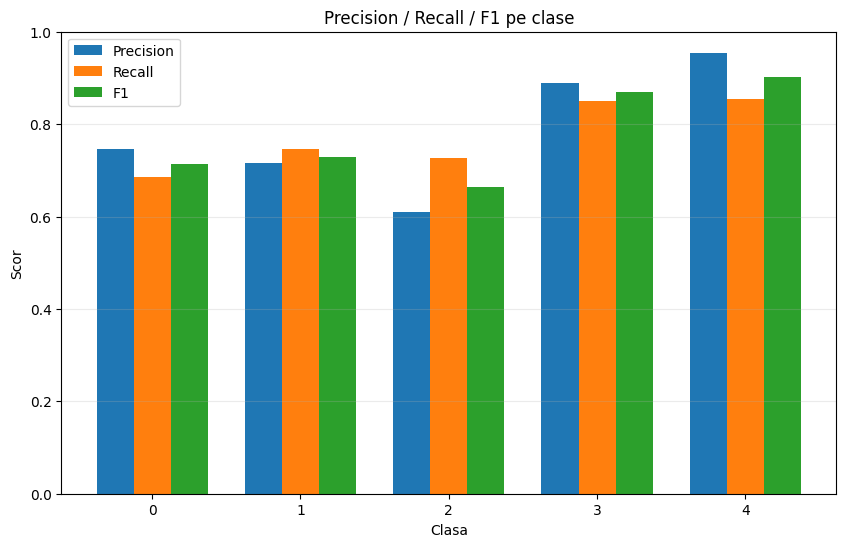

              precision    recall  f1-score   support

           0       0.75      0.68      0.71      1250
           1       0.71      0.75      0.73      1221
           2       0.61      0.73      0.66      1250
           3       0.89      0.85      0.87      1250
           4       0.95      0.85      0.90      1250

    accuracy                           0.77      6221
   macro avg       0.78      0.77      0.78      6221
weighted avg       0.78      0.77      0.78      6221



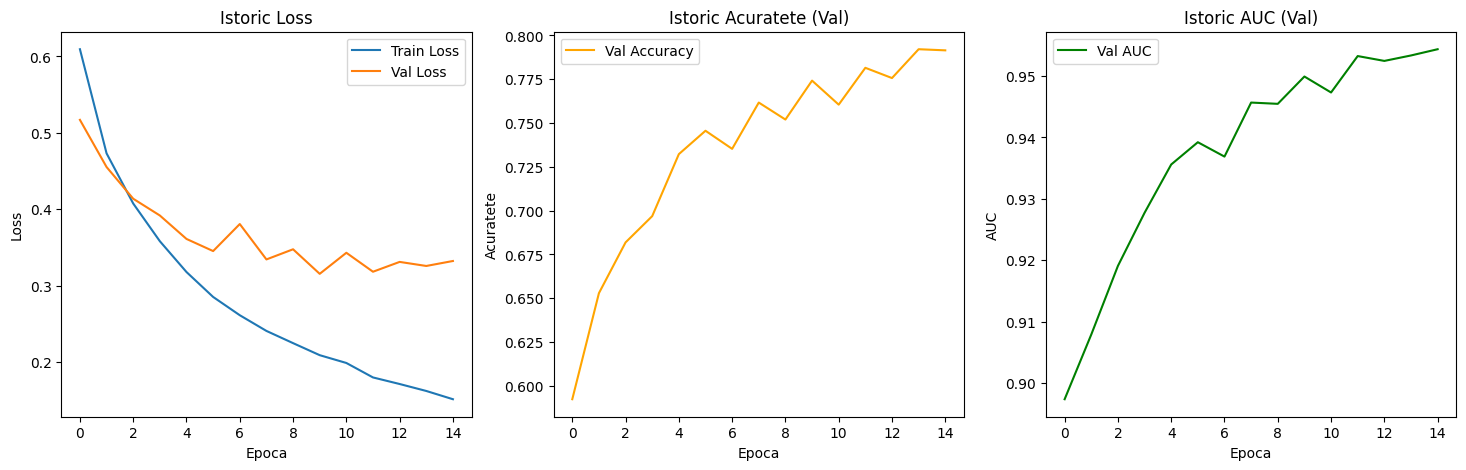

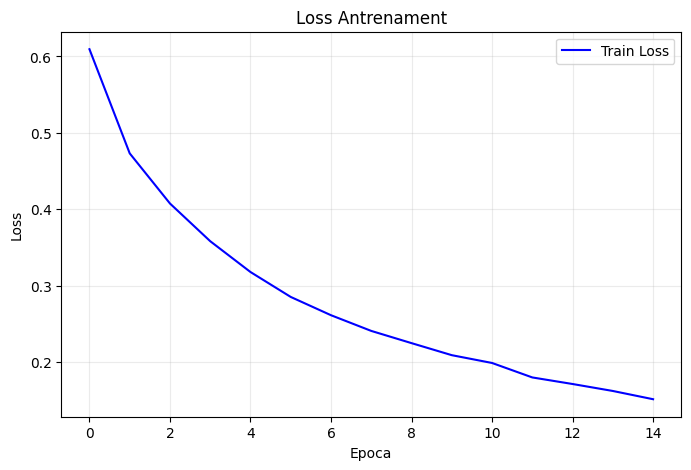

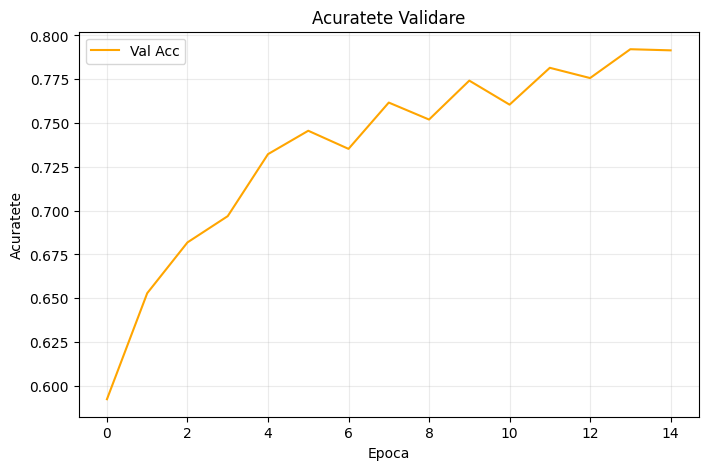

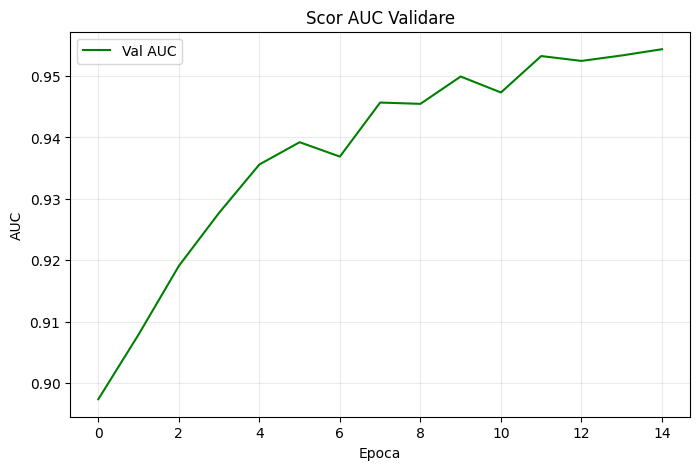

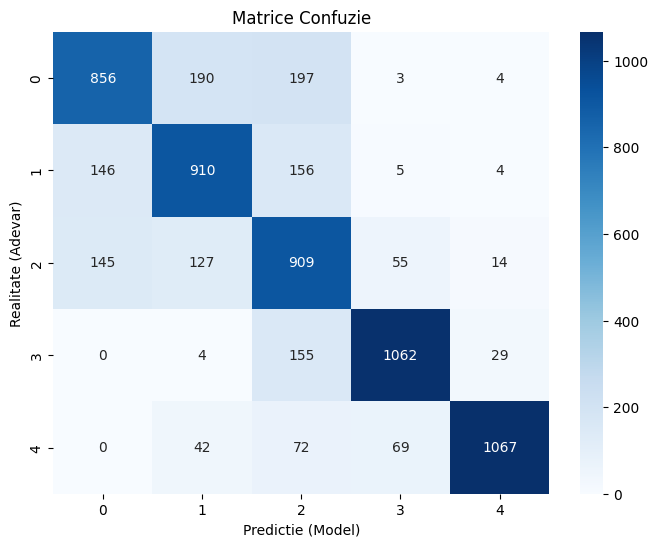

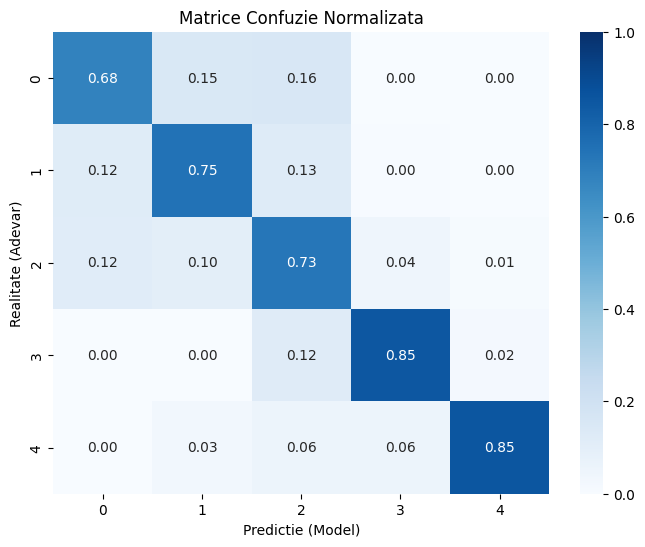

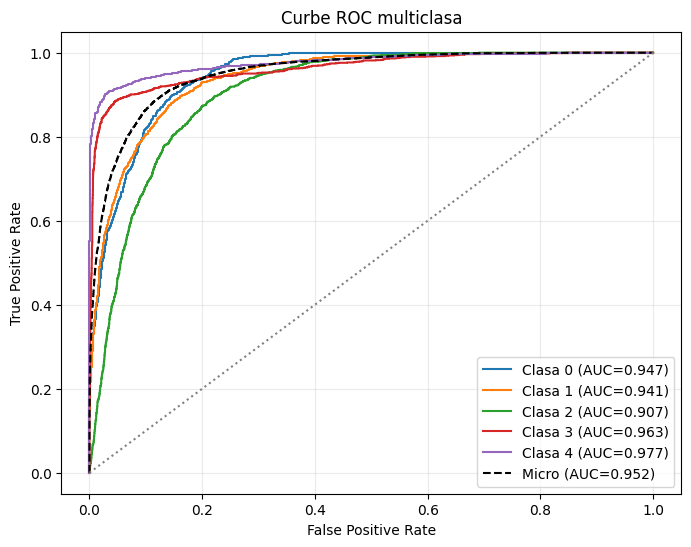

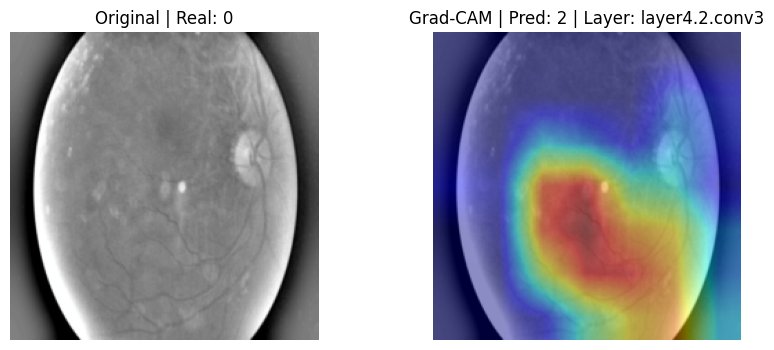


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_balanced_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_balanced_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_balanced_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_balanced_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_balanced_aptos_

In [4]:
# 1. Diabetic_Balanced_Data + APTOS train, Diabetic_Balanced_Data + APTOS test
%run Clasificare_datasets_balanced/train.py --experiment balanced_aptos_to_balanced_aptos --model resnet50 --loss_name focal_loss --epochs 15 --batch_size 32 --num_workers 8 --lr 0.0001

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: balanced_aptos_to_aptos | TRAIN/VAL=combined | TEST=aptos
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=42292 | VALIDARE=10940 | TESTARE=1250


Ep 01/15 | T_Loss: 0.6099 | V_Loss: 0.5014 | V_Acc: 62.8% | V_AUC: 0.8948 NOU BEST
Durata epoca: 7.70 min


Ep 02/15 | T_Loss: 0.4747 | V_Loss: 0.4856 | V_Acc: 62.2% | V_AUC: 0.9049 NOU BEST
Durata epoca: 7.88 min


Ep 03/15 | T_Loss: 0.4133 | V_Loss: 0.4213 | V_Acc: 68.3% | V_AUC: 0.9191 NOU BEST
Durata epoca: 8.13 min


Ep 04/15 | T_Loss: 0.3585 | V_Loss: 0.4176 | V_Acc: 69.4% | V_AUC: 0.9243 NOU BEST
Durata epoca: 8.08 min


...

Ep 12/15 | T_Loss: 0.1813 | V_Loss: 0.3305 | V_Acc: 77.2% | V_AUC: 0.9511 NOU BEST
Durata epoca: 6.70 min


Ep 13/15 | T_Loss: 0.1693 | V_Loss: 0.3279 | V_Acc: 77.6% | V_AUC: 0.9525 NOU BEST
Durata epoca: 6.83 min


Ep 14/15 | T_Loss: 0.1594 | V_Loss: 0.3724 | V_Acc: 76.5% | V_AUC: 0.9479 
Durata epoca: 6.85 min


Ep 15/15 | T_Loss: 0.1508 | V_Loss: 0.3256 | V_Acc: 79.1% | V_AUC: 0.9561 NOU BEST
Durata epoca: 6.40 min

START TEST FINAL: aptos


Rezultate testare finala:
   Acuratete: 63.92%
   Scor AUC:  0.8846
   Loss:      1.0966

Classification report:


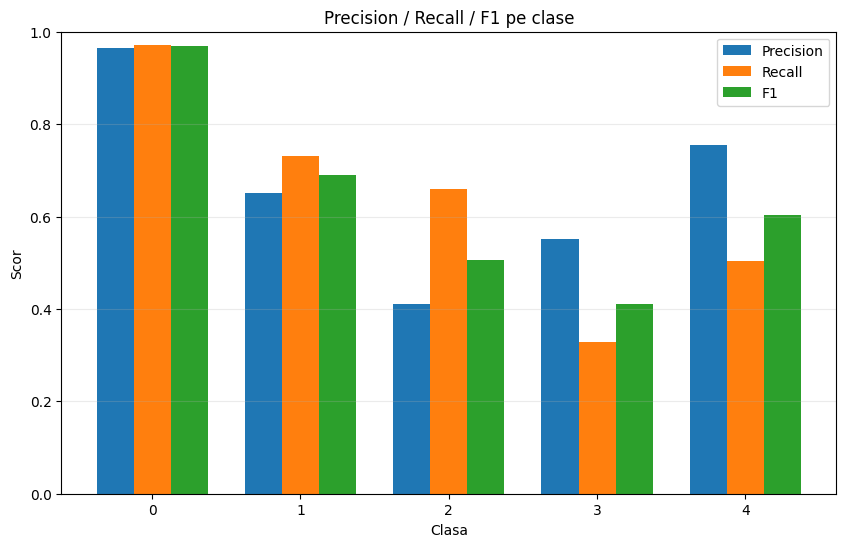

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       250
           1       0.65      0.73      0.69       250
           2       0.41      0.66      0.51       250
           3       0.55      0.33      0.41       250
           4       0.75      0.50      0.60       250

    accuracy                           0.64      1250
   macro avg       0.67      0.64      0.64      1250
weighted avg       0.67      0.64      0.64      1250



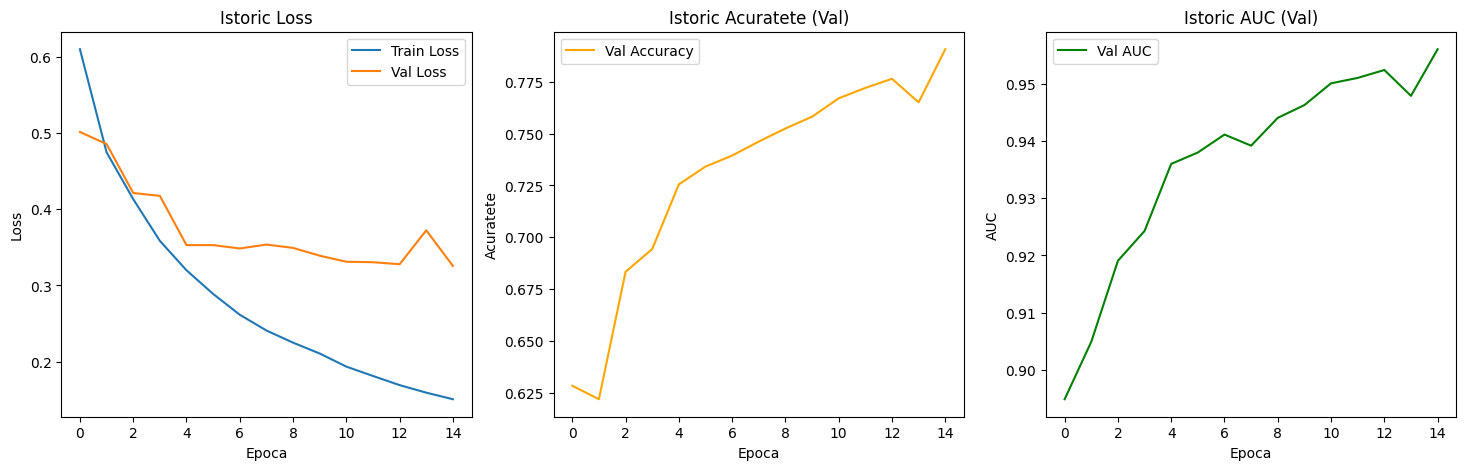

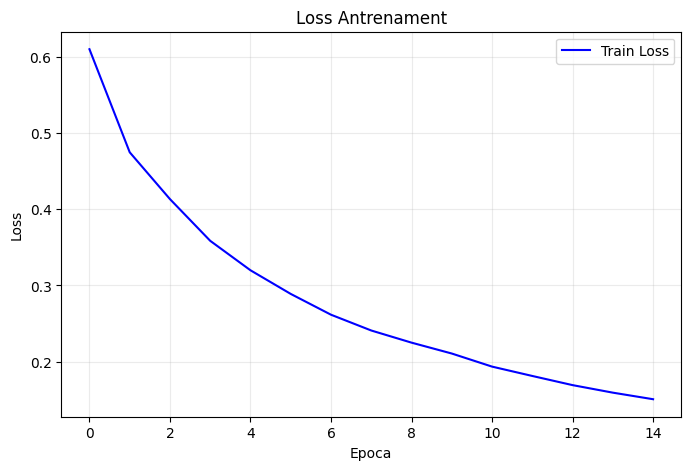

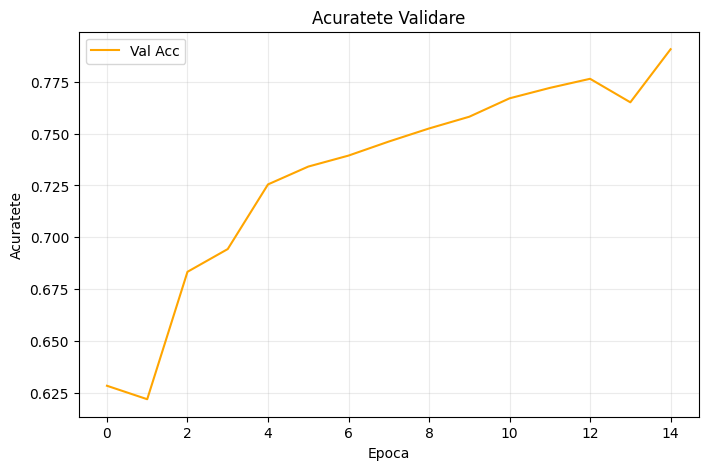

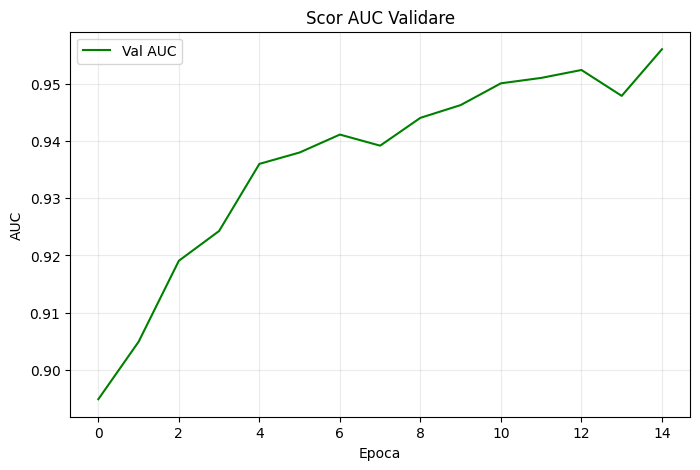

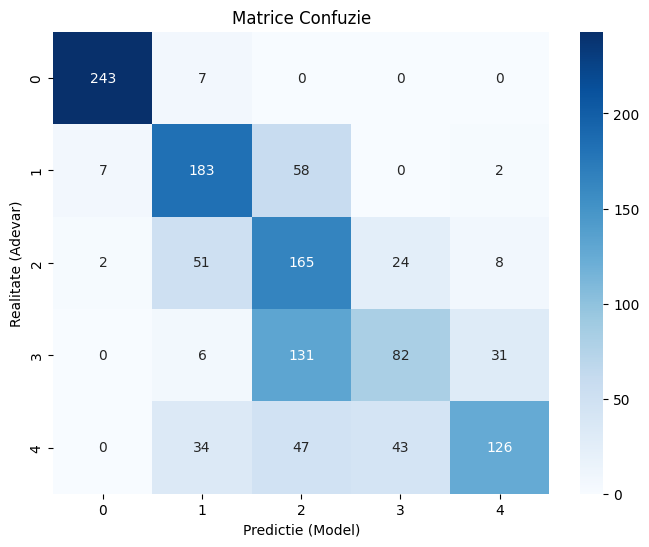

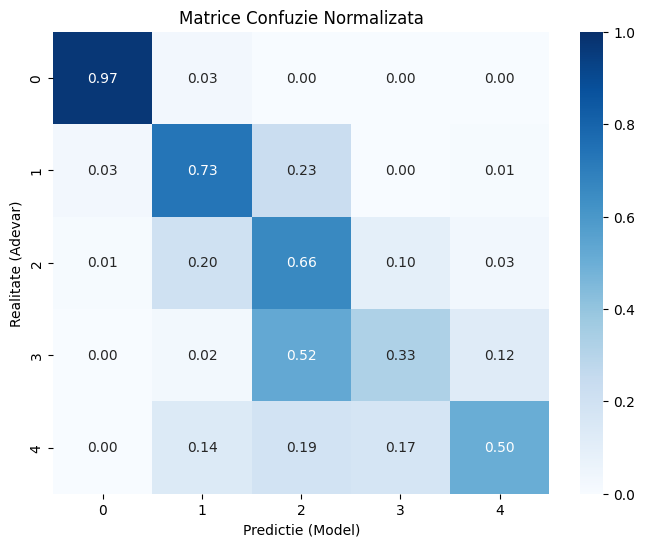

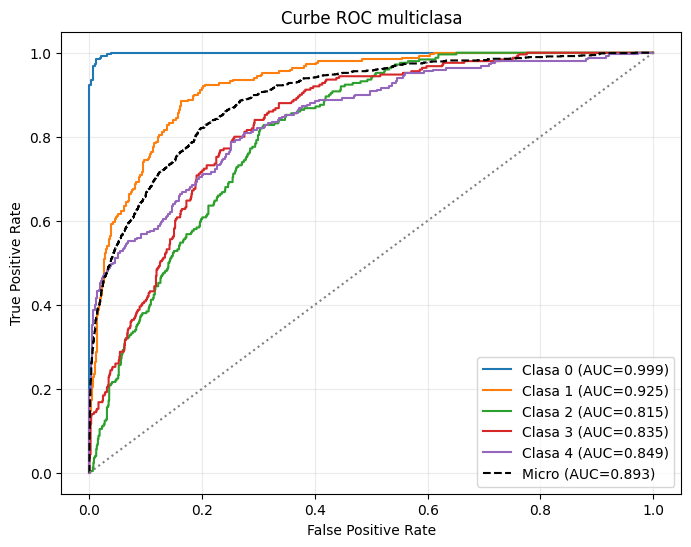

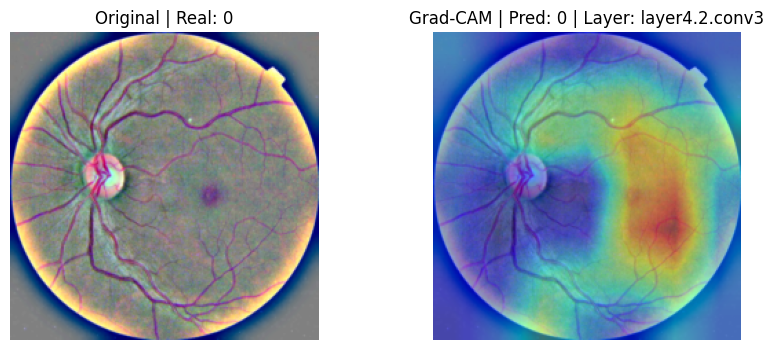


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_balanced_aptos_to_aptos_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_balanced_aptos_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_balanced_aptos_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_balanced_aptos_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_balanced_aptos_to_aptos_resnet50_focal_loss_adam_LR

In [1]:
# 2. Diabetic_Balanced_Data + APTOS train, APTOS test
%run Clasificare_datasets_balanced/train.py --experiment balanced_aptos_to_aptos --model resnet50 --loss_name focal_loss --epochs 15 --batch_size 32 --num_workers 8 --lr 0.0001

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: balanced_aptos_to_balanced | TRAIN/VAL=combined | TEST=balanced
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=42292 | VALIDARE=10940 | TESTARE=4971


Ep 01/15 | T_Loss: 0.6159 | V_Loss: 0.5195 | V_Acc: 61.8% | V_AUC: 0.8893 NOU BEST
Durata epoca: 6.86 min


Ep 02/15 | T_Loss: 0.4759 | V_Loss: 0.4340 | V_Acc: 66.9% | V_AUC: 0.9144 NOU BEST
Durata epoca: 6.98 min


Ep 03/15 | T_Loss: 0.4123 | V_Loss: 0.4176 | V_Acc: 68.2% | V_AUC: 0.9189 NOU BEST
Durata epoca: 6.65 min


Ep 04/15 | T_Loss: 0.3602 | V_Loss: 0.3877 | V_Acc: 70.8% | V_AUC: 0.9275 NOU BEST
Durata epoca: 6.32 min


...

Ep 12/15 | T_Loss: 0.1807 | V_Loss: 0.3075 | V_Acc: 78.4% | V_AUC: 0.9530 NOU BEST
Durata epoca: 6.34 min


Ep 13/15 | T_Loss: 0.1701 | V_Loss: 0.3113 | V_Acc: 78.3% | V_AUC: 0.9531 NOU BEST
Durata epoca: 6.15 min


Ep 14/15 | T_Loss: 0.1590 | V_Loss: 0.3068 | V_Acc: 78.8% | V_AUC: 0.9561 NOU BEST
Durata epoca: 6.33 min


Ep 15/15 | T_Loss: 0.1485 | V_Loss: 0.3052 | V_Acc: 79.3% | V_AUC: 0.9565 NOU BEST
Durata epoca: 6.31 min

START TEST FINAL: balanced


Rezultate testare finala:
   Acuratete: 79.48%
   Scor AUC:  0.9581
   Loss:      0.2487

Classification report:


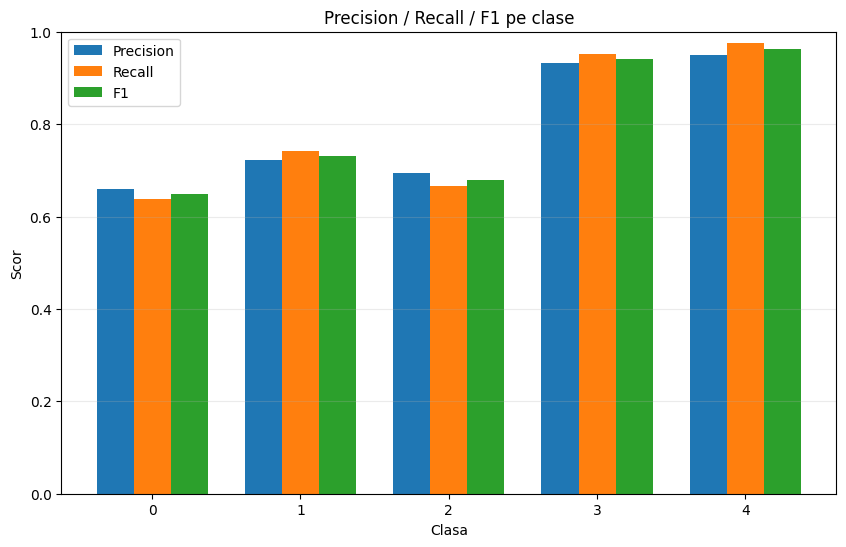

              precision    recall  f1-score   support

           0       0.66      0.64      0.65      1000
           1       0.72      0.74      0.73       971
           2       0.69      0.67      0.68      1000
           3       0.93      0.95      0.94      1000
           4       0.95      0.97      0.96      1000

    accuracy                           0.79      4971
   macro avg       0.79      0.79      0.79      4971
weighted avg       0.79      0.79      0.79      4971



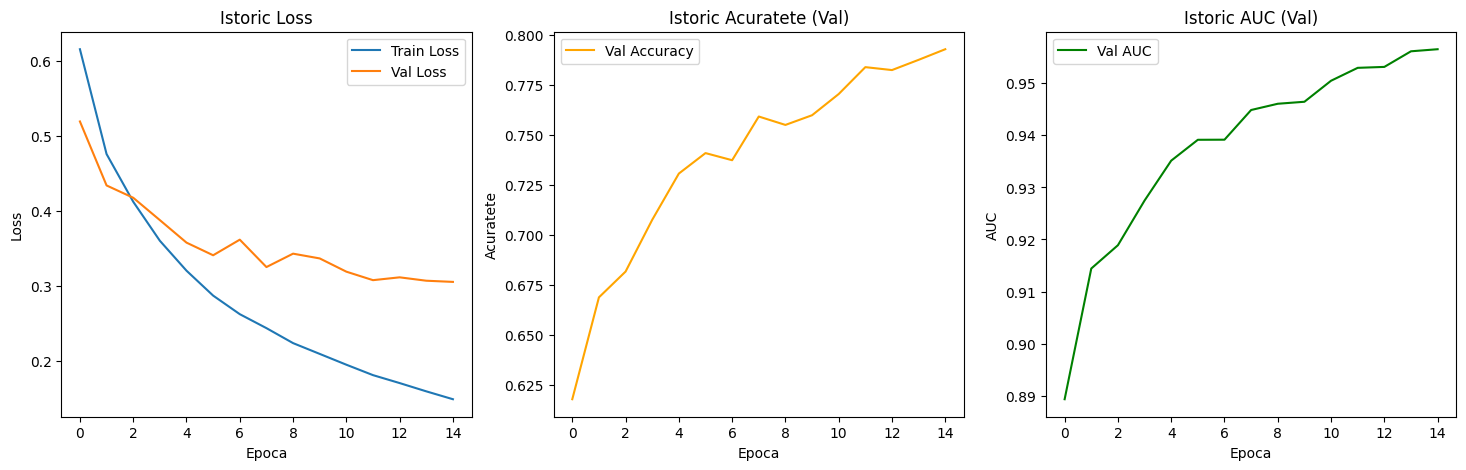

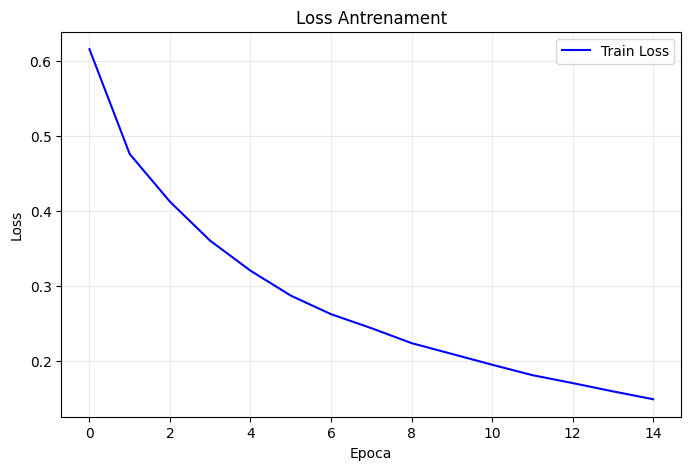

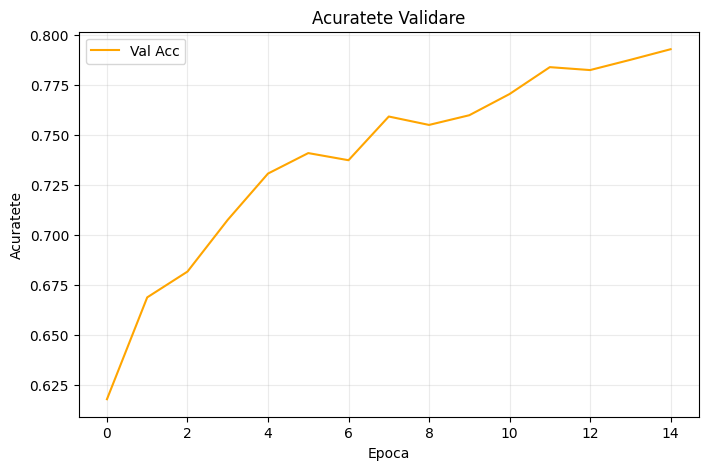

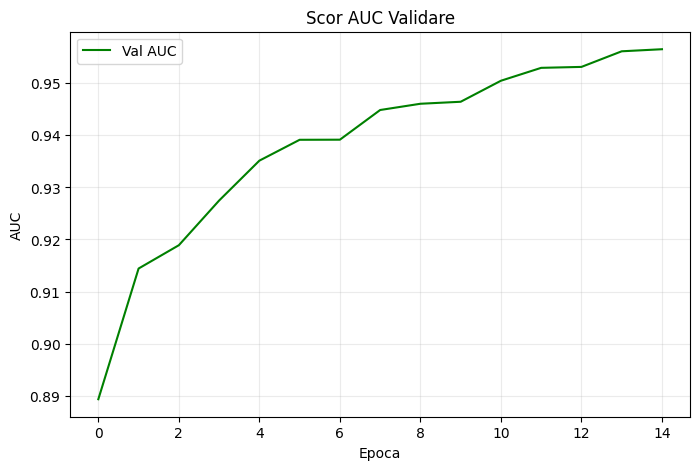

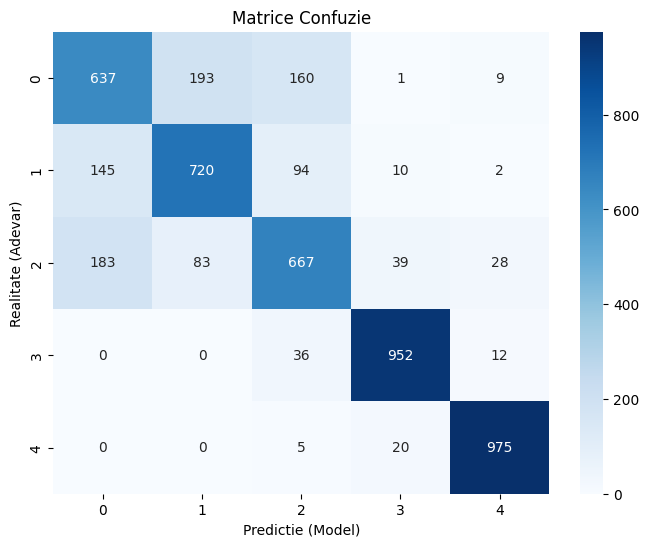

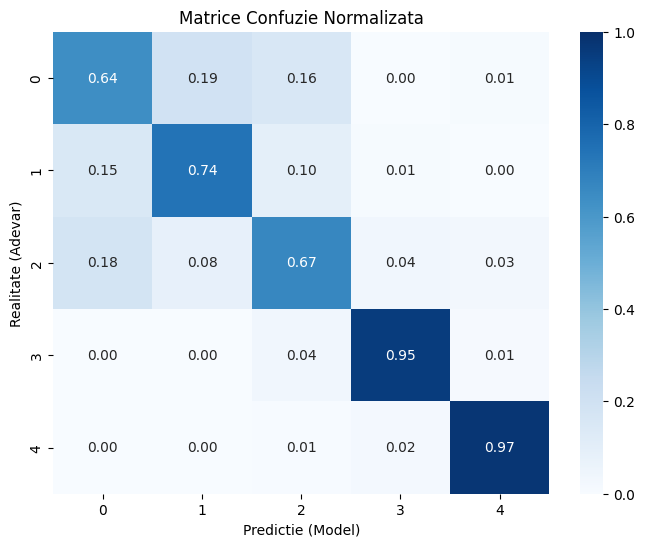

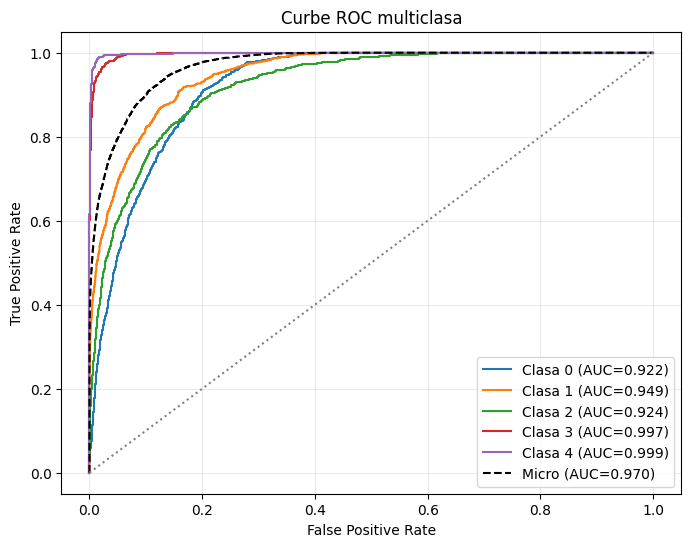

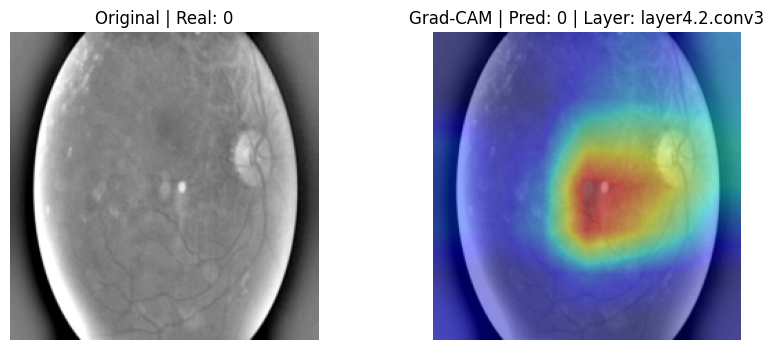


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_balanced_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_balanced_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_balanced_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_balanced_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_balanced_aptos_to_balanced_resnet50_foc

In [1]:
# 3. Diabetic_Balanced_Data + APTOS train, Diabetic_Balanced_Data test
%run Clasificare_datasets_balanced/train.py --experiment balanced_aptos_to_balanced --model resnet50 --loss_name focal_loss --epochs 15 --batch_size 32 --num_workers 8 --lr 0.0001

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: aptos_to_balanced | TRAIN/VAL=aptos | TEST=balanced
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=7500 | VALIDARE=1000 | TESTARE=4971


Ep 01/25 | T_Loss: 0.6059 | V_Loss: 0.5623 | V_Acc: 63.2% | V_AUC: 0.8744 NOU BEST
Durata epoca: 1.61 min


Ep 02/25 | T_Loss: 0.3119 | V_Loss: 0.5837 | V_Acc: 65.1% | V_AUC: 0.8896 NOU BEST
Durata epoca: 1.60 min


Ep 03/25 | T_Loss: 0.1959 | V_Loss: 0.8220 | V_Acc: 63.3% | V_AUC: 0.8838 
Durata epoca: 1.61 min


Ep 04/25 | T_Loss: 0.1367 | V_Loss: 0.7718 | V_Acc: 65.5% | V_AUC: 0.8792 
Durata epoca: 1.60 min


...

Ep 22/25 | T_Loss: 0.0099 | V_Loss: 1.1525 | V_Acc: 66.5% | V_AUC: 0.8930 
Durata epoca: 1.61 min


Ep 23/25 | T_Loss: 0.0096 | V_Loss: 1.2208 | V_Acc: 65.1% | V_AUC: 0.8952 
Durata epoca: 1.61 min


Ep 24/25 | T_Loss: 0.0102 | V_Loss: 1.2630 | V_Acc: 64.9% | V_AUC: 0.8911 
Durata epoca: 1.60 min


Ep 25/25 | T_Loss: 0.0100 | V_Loss: 1.2918 | V_Acc: 64.2% | V_AUC: 0.8923 
Durata epoca: 1.60 min

START TEST FINAL: balanced


Rezultate testare finala:
   Acuratete: 30.34%
   Scor AUC:  0.6352
   Loss:      2.2794

Classification report:


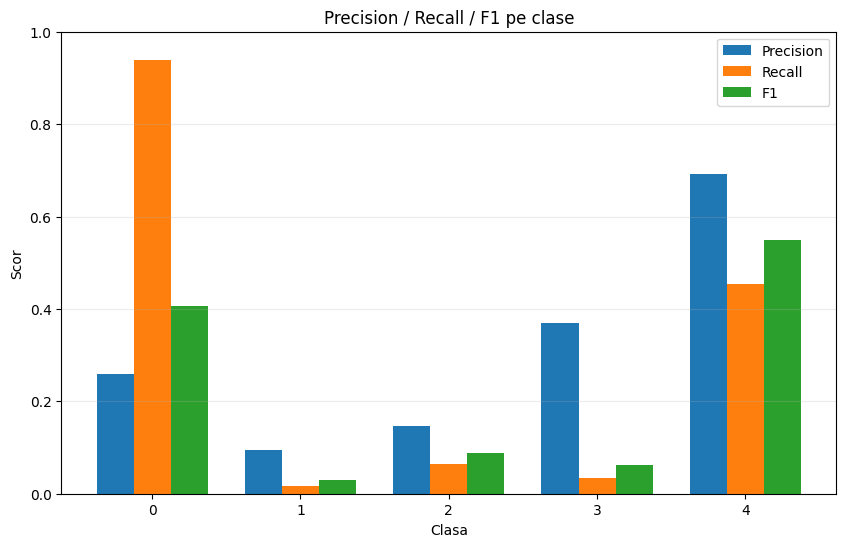

              precision    recall  f1-score   support

           0       0.26      0.94      0.41      1000
           1       0.09      0.02      0.03       971
           2       0.15      0.06      0.09      1000
           3       0.37      0.03      0.06      1000
           4       0.69      0.46      0.55      1000

    accuracy                           0.30      4971
   macro avg       0.31      0.30      0.23      4971
weighted avg       0.31      0.30      0.23      4971



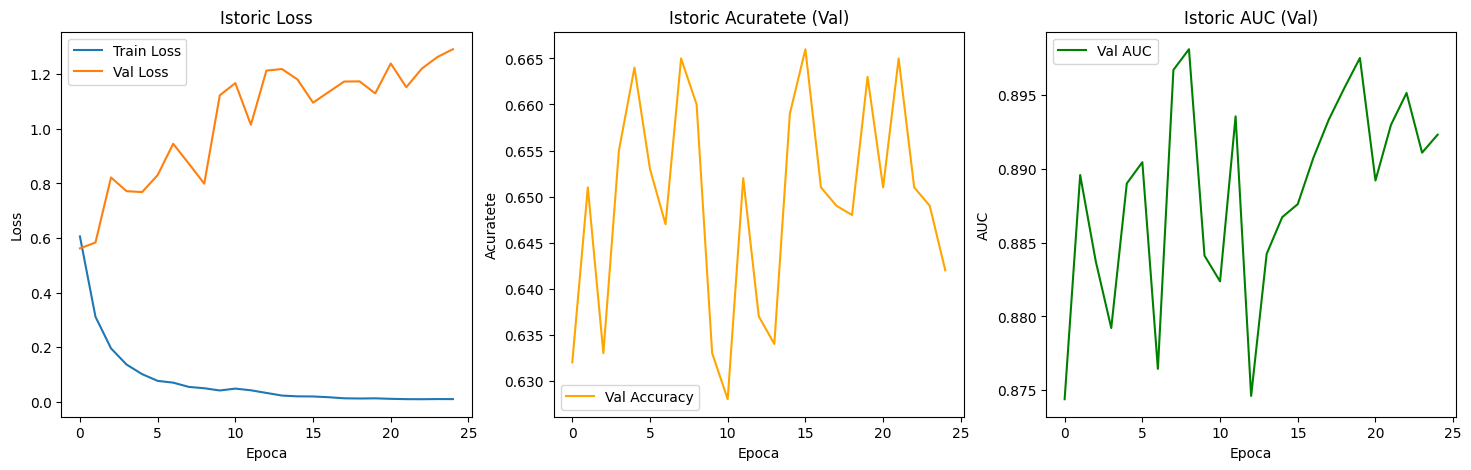

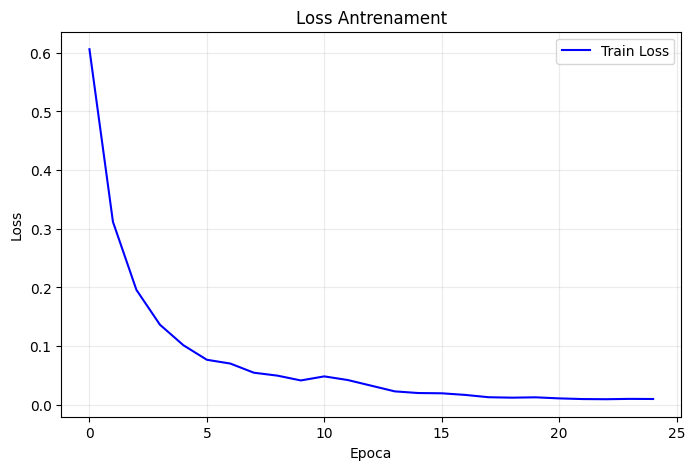

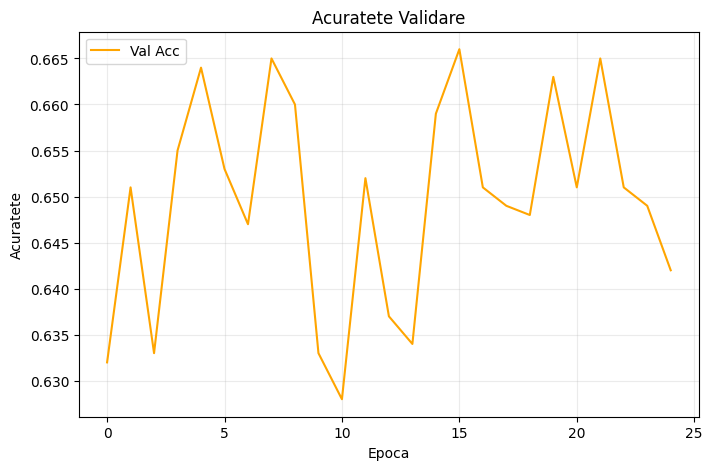

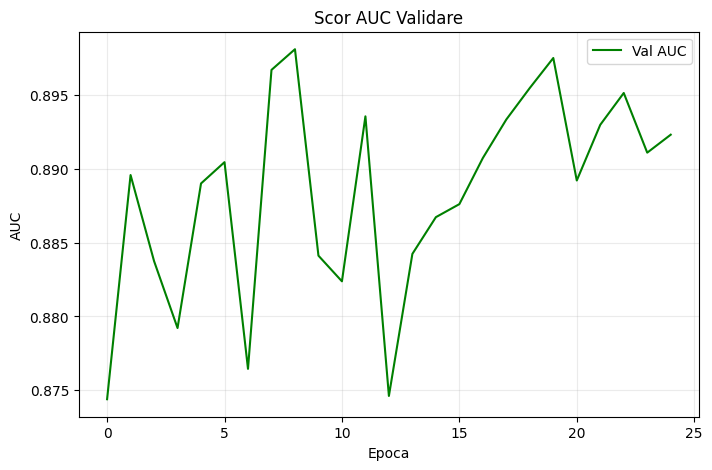

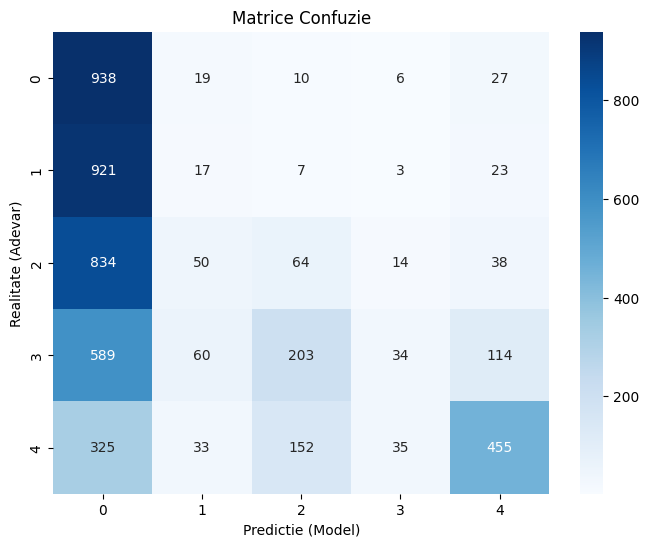

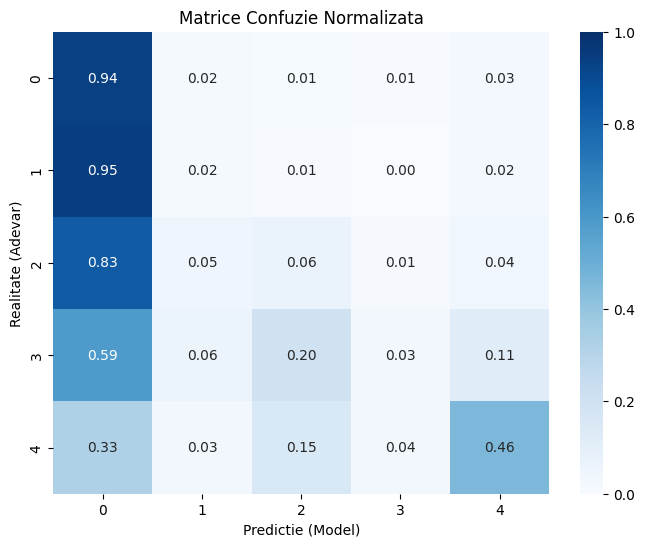

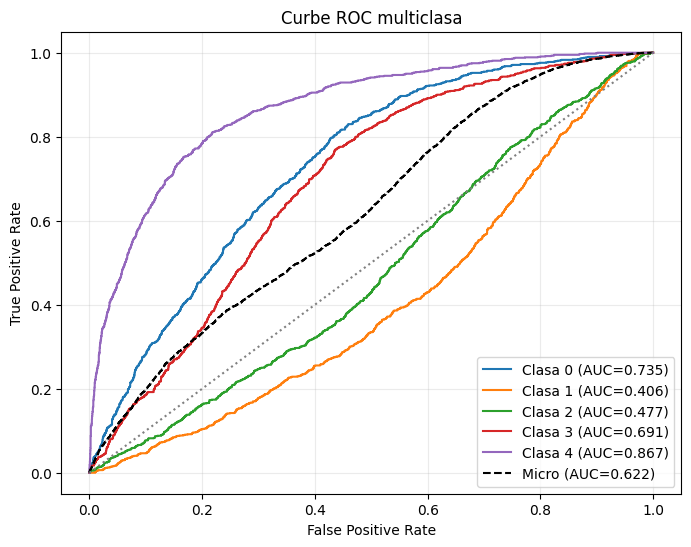

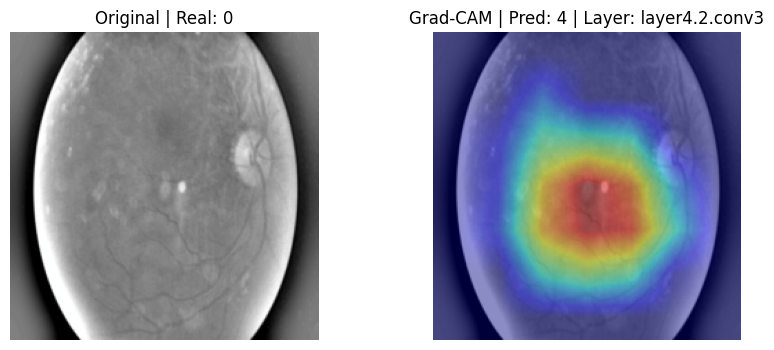


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_aptos_to_balanced_resnet50_focal_loss_adam_LR_0.0001.png
Matrice confuzie: 

In [2]:
# 4. APTOS train, Diabetic_Balanced_Data test
%run Clasificare_datasets_balanced/train.py --experiment aptos_to_balanced --model resnet50 --loss_name focal_loss --epochs 25 --batch_size 32 --num_workers 8 --lr 0.0001

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: aptos_to_balanced_aptos | TRAIN/VAL=aptos | TEST=combined
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=7500 | VALIDARE=1000 | TESTARE=6221


Ep 01/25 | T_Loss: 0.6484 | V_Loss: 0.5947 | V_Acc: 60.1% | V_AUC: 0.8676 NOU BEST
Durata epoca: 1.58 min


Ep 02/25 | T_Loss: 0.3303 | V_Loss: 0.5960 | V_Acc: 65.3% | V_AUC: 0.8899 NOU BEST
Durata epoca: 1.62 min


Ep 03/25 | T_Loss: 0.2023 | V_Loss: 0.6486 | V_Acc: 68.1% | V_AUC: 0.8971 NOU BEST
Durata epoca: 1.61 min


Ep 04/25 | T_Loss: 0.1352 | V_Loss: 0.8369 | V_Acc: 64.3% | V_AUC: 0.8834 
Durata epoca: 1.61 min


...

Ep 22/25 | T_Loss: 0.0115 | V_Loss: 1.2269 | V_Acc: 65.8% | V_AUC: 0.8835 
Durata epoca: 1.61 min


Ep 23/25 | T_Loss: 0.0115 | V_Loss: 1.2546 | V_Acc: 66.1% | V_AUC: 0.8797 
Durata epoca: 1.62 min


Ep 24/25 | T_Loss: 0.0111 | V_Loss: 1.2466 | V_Acc: 66.1% | V_AUC: 0.8851 
Durata epoca: 1.61 min


Ep 25/25 | T_Loss: 0.0116 | V_Loss: 1.3375 | V_Acc: 65.0% | V_AUC: 0.8798 
Durata epoca: 1.62 min

START TEST FINAL: combined


Rezultate testare finala:
   Acuratete: 34.71%
   Scor AUC:  0.6846
   Loss:      2.0734

Classification report:


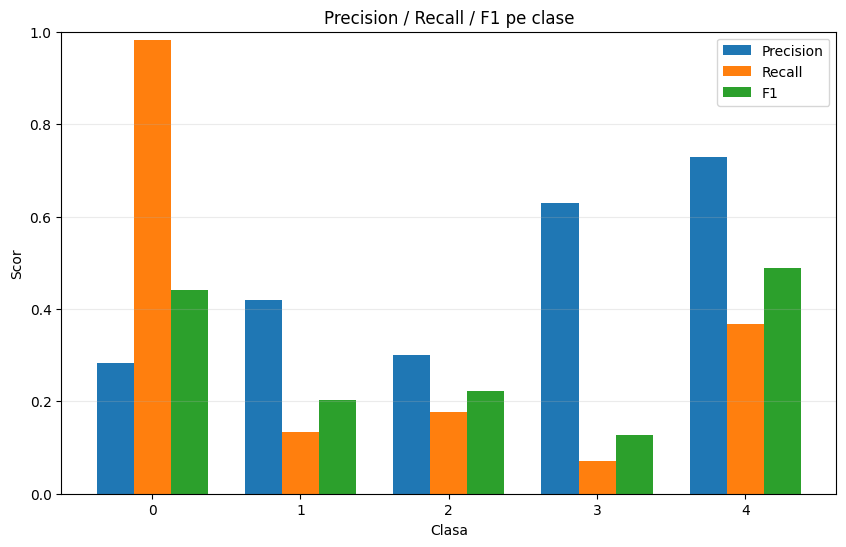

              precision    recall  f1-score   support

           0       0.28      0.98      0.44      1250
           1       0.42      0.13      0.20      1221
           2       0.30      0.18      0.22      1250
           3       0.63      0.07      0.13      1250
           4       0.73      0.37      0.49      1250

    accuracy                           0.35      6221
   macro avg       0.47      0.35      0.30      6221
weighted avg       0.47      0.35      0.30      6221



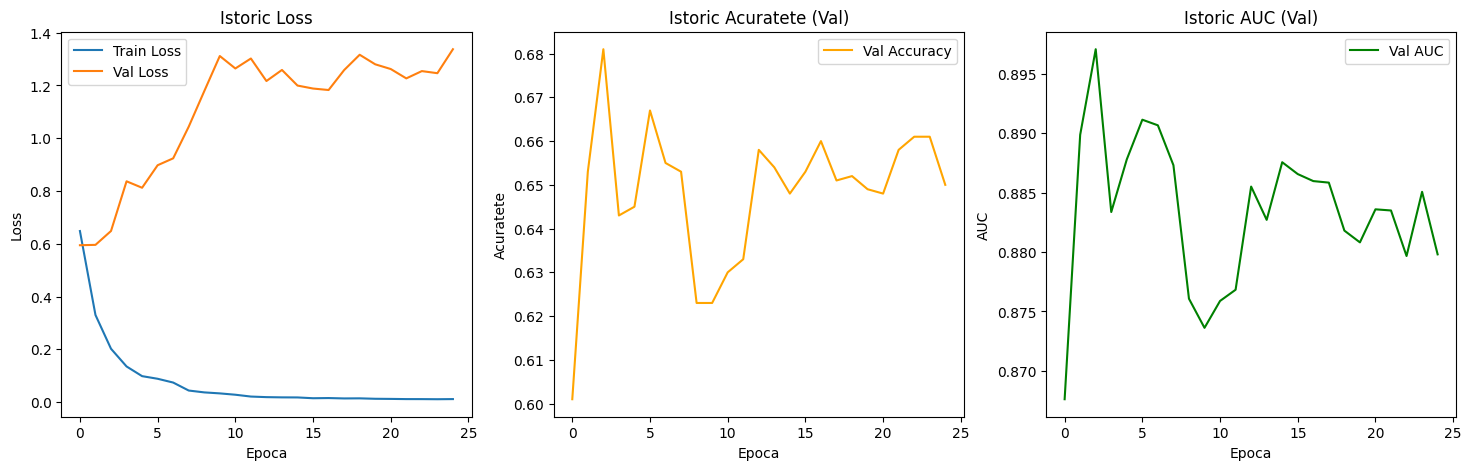

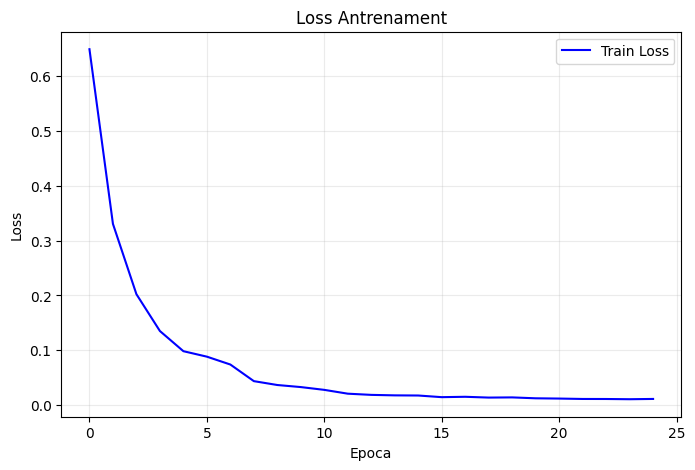

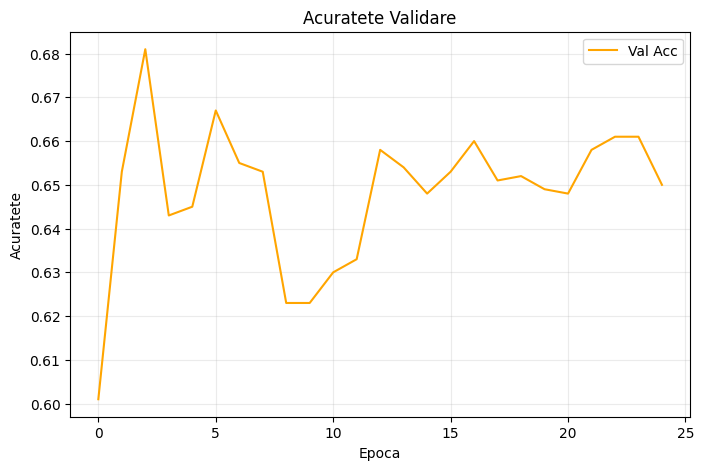

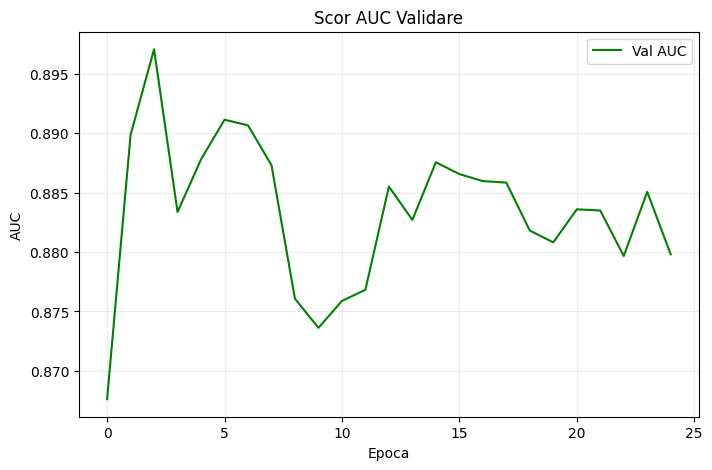

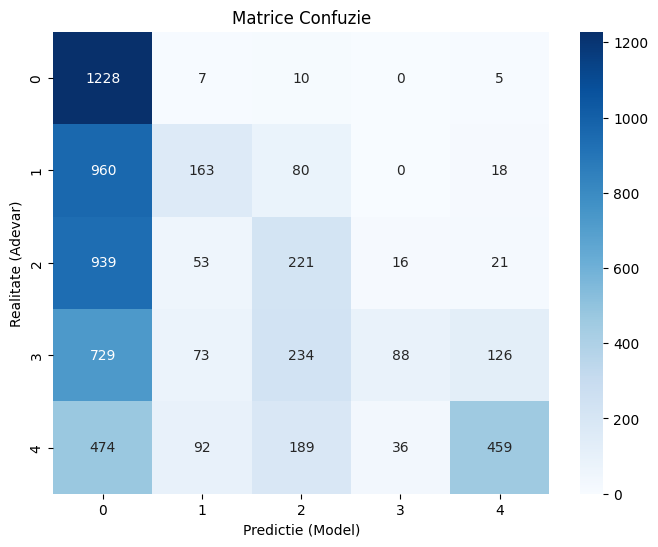

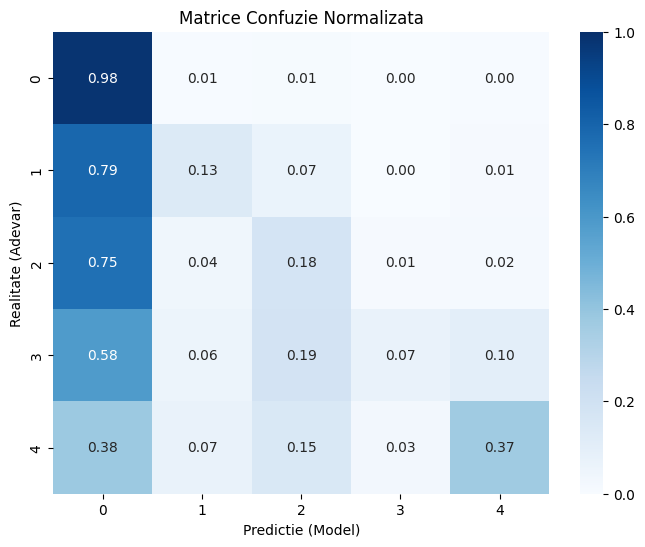

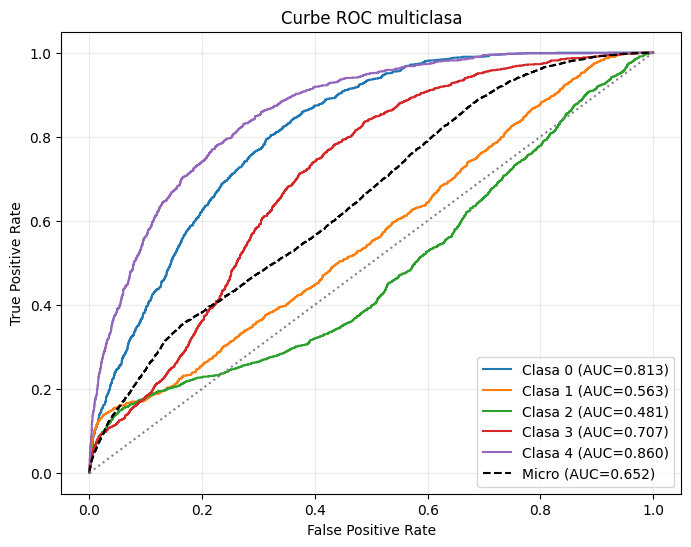

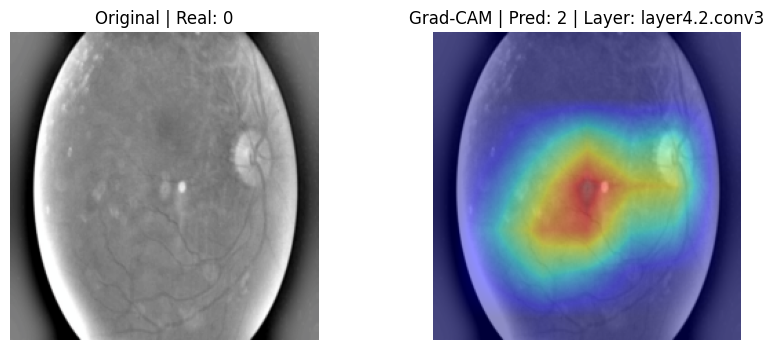


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_aptos_to_balanced_aptos_resnet50_focal_loss_adam_LR

In [3]:
# 5. APTOS train, Diabetic_Balanced_Data + APTOS test
%run Clasificare_datasets_balanced/train.py --experiment aptos_to_balanced_aptos --model resnet50 --loss_name focal_loss --epochs 25 --batch_size 32 --num_workers 8 --lr 0.0001

Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
Experiment: balanced_to_aptos | TRAIN/VAL=balanced | TEST=aptos
Balanced root: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\Diabetic_Balanced_Data
APTOS root:    b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\datasets\aptos\aptos_ben_graham
Distributie date: TRAIN=34792 | VALIDARE=9940 | TESTARE=1250


Ep 01/15 | T_Loss: 0.6307 | V_Loss: 0.5174 | V_Acc: 61.0% | V_AUC: 0.8886 NOU BEST
Durata epoca: 6.14 min


Ep 02/15 | T_Loss: 0.5019 | V_Loss: 0.4760 | V_Acc: 63.4% | V_AUC: 0.9013 NOU BEST
Durata epoca: 5.23 min


Ep 03/15 | T_Loss: 0.4446 | V_Loss: 0.3858 | V_Acc: 68.9% | V_AUC: 0.9215 NOU BEST
Durata epoca: 5.14 min


Ep 04/15 | T_Loss: 0.3922 | V_Loss: 0.3814 | V_Acc: 70.3% | V_AUC: 0.9271 NOU BEST
Durata epoca: 5.10 min


...

Ep 12/15 | T_Loss: 0.1983 | V_Loss: 0.2745 | V_Acc: 78.2% | V_AUC: 0.9528 NOU BEST
Durata epoca: 5.20 min


Ep 13/15 | T_Loss: 0.1843 | V_Loss: 0.2501 | V_Acc: 80.0% | V_AUC: 0.9592 NOU BEST
Durata epoca: 5.15 min


Ep 14/15 | T_Loss: 0.1692 | V_Loss: 0.2399 | V_Acc: 81.1% | V_AUC: 0.9608 NOU BEST
Durata epoca: 5.11 min


Ep 15/15 | T_Loss: 0.1613 | V_Loss: 0.2561 | V_Acc: 80.2% | V_AUC: 0.9597 
Durata epoca: 5.09 min

START TEST FINAL: aptos


Rezultate testare finala:
   Acuratete: 40.40%
   Scor AUC:  0.7434
   Loss:      1.6162

Classification report:


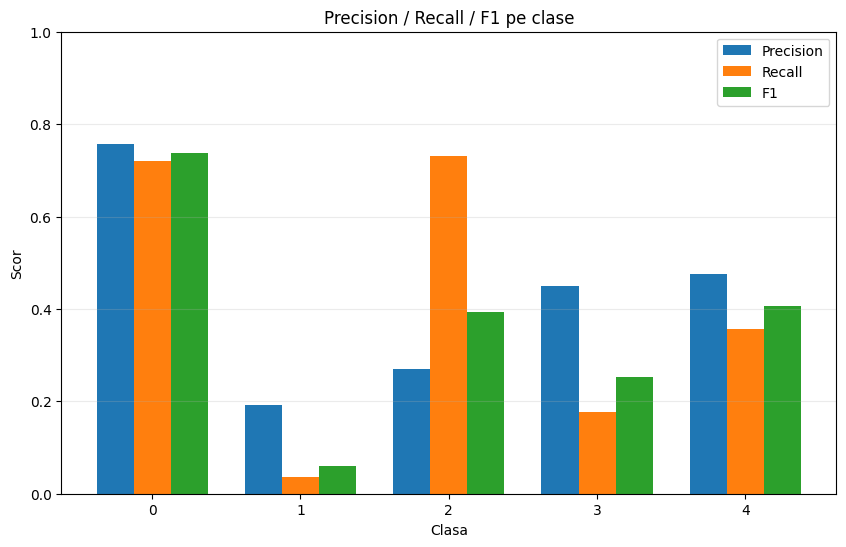

              precision    recall  f1-score   support

           0       0.76      0.72      0.74       250
           1       0.19      0.04      0.06       250
           2       0.27      0.73      0.39       250
           3       0.45      0.18      0.25       250
           4       0.48      0.36      0.41       250

    accuracy                           0.40      1250
   macro avg       0.43      0.40      0.37      1250
weighted avg       0.43      0.40      0.37      1250



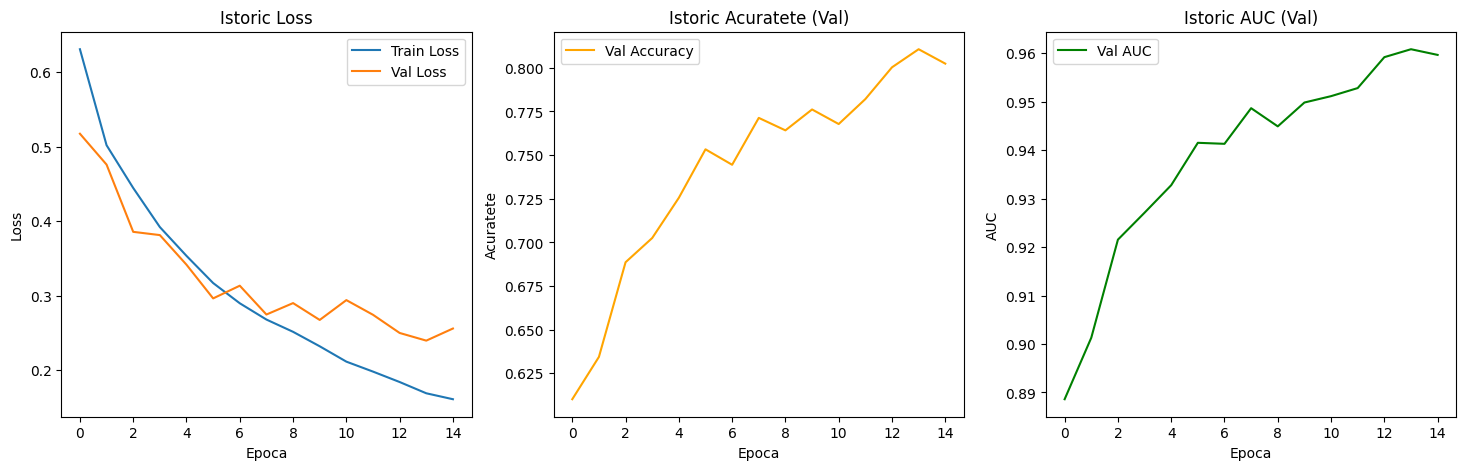

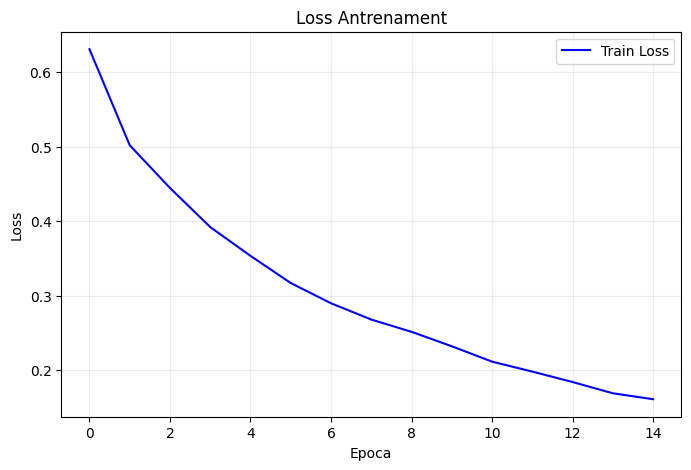

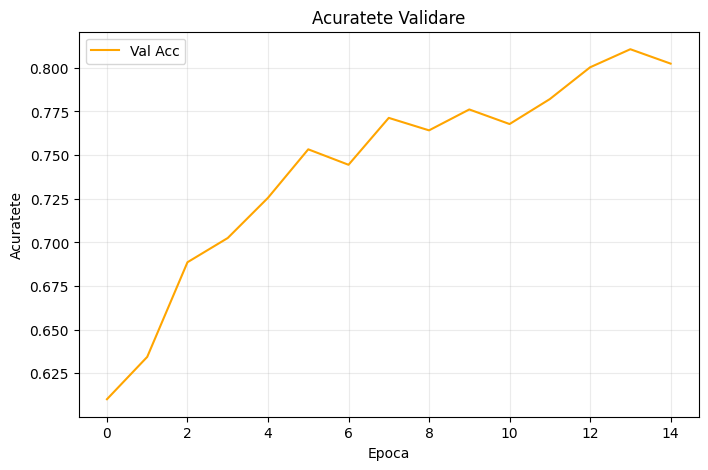

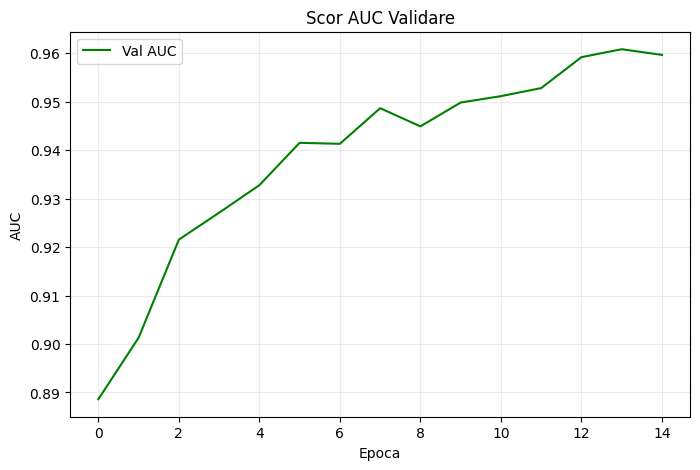

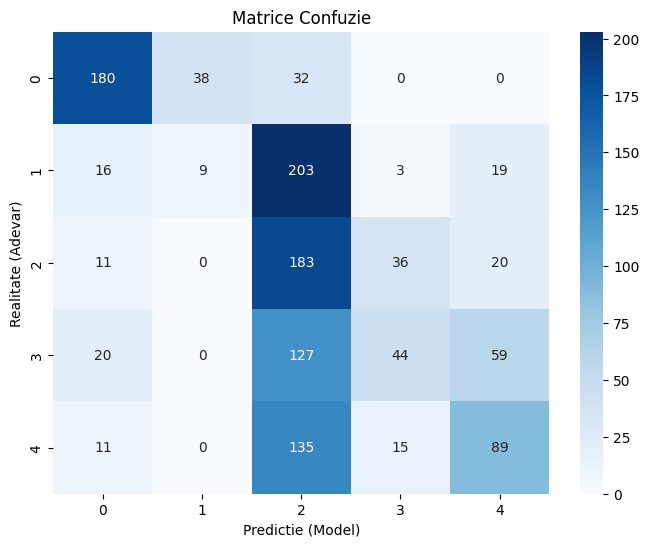

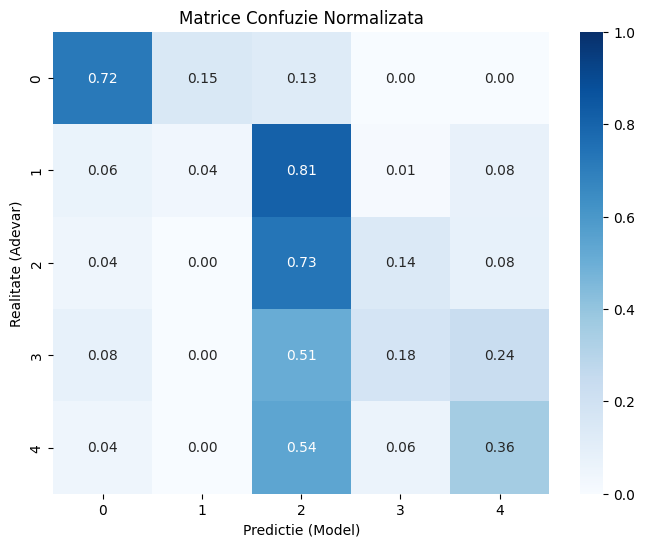

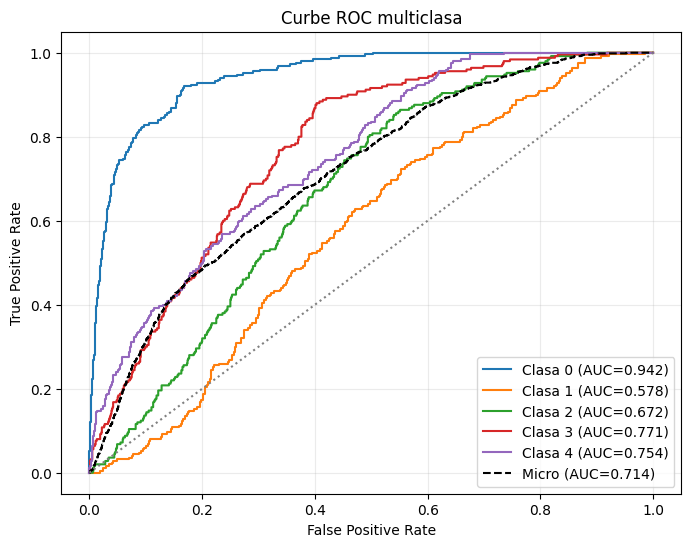

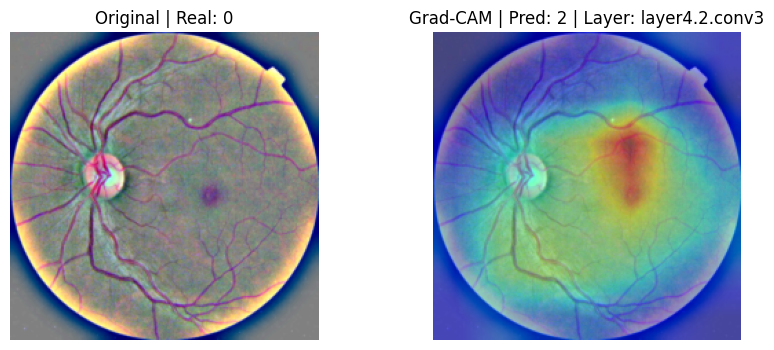


Gata. Model: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\modele\best_balanced_to_aptos_resnet50_focal_loss_adam_LR_0.0001.pth
Grafic evolutie combinat: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\istoric_combinat_balanced_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic loss: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\loss_balanced_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic acuratete: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\acc_balanced_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Grafic AUC: b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier-V2\Notebooks\Clasificare_datasets_balanced\Rezultate\grafice\auc_balanced_to_aptos_resnet50_focal_loss_adam_LR_0.0001.png
Matrice confuzie: 

In [4]:
# 6. Diabetic_Balanced_Data train, APTOS test
%run Clasificare_datasets_balanced/train.py --experiment balanced_to_aptos --model resnet50 --loss_name focal_loss --epochs 15 --batch_size 32 --num_workers 8 --lr 0.0001

## Partea 1: Evaluarea datasetului Balanced (Clasificare_datasets_balanced)
Se verifica arhitectura ResNet50 + focal_loss/CrossEntropyLoss/Weighted_Ce + InceptionV3 + IncResV2

*Notă: Modelele Inception necesită rezoluție 299x299.*

🔥 Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 0.5416 | V_Loss: 0.4130 | V_Acc: 62.3% | V_AUC: 0.8919 🌟 NOU BEST
Durată Epocă: 6.34 min


Ep 02/20 | T_Loss: 0.4296 | V_Loss: 0.3651 | V_Acc: 65.8% | V_AUC: 0.9093 🌟 NOU BEST
Durată Epocă: 6.22 min


Ep 03/20 | T_Loss: 0.3765 | V_Loss: 0.3277 | V_Acc: 68.1% | V_AUC: 0.9198 🌟 NOU BEST
Durată Epocă: 6.12 min


Ep 04/20 | T_Loss: 0.3333 | V_Loss: 0.2980 | V_Acc: 70.8% | V_AUC: 0.9269 🌟 NOU BEST
Durată Epocă: 6.04 min


...

Ep 17/20 | T_Loss: 0.1097 | V_Loss: 0.1845 | V_Acc: 82.0% | V_AUC: 0.9649 🌟 NOU BEST
Durată Epocă: 6.00 min


Ep 18/20 | T_Loss: 0.0987 | V_Loss: 0.2162 | V_Acc: 80.9% | V_AUC: 0.9637 
Durată Epocă: 6.01 min


Ep 19/20 | T_Loss: 0.0952 | V_Loss: 0.1850 | V_Acc: 83.2% | V_AUC: 0.9672 🌟 NOU BEST
Durată Epocă: 6.02 min


Ep 20/20 | T_Loss: 0.0880 | V_Loss: 0.1895 | V_Acc: 83.2% | V_AUC: 0.9683 🌟 NOU BEST
Durată Epocă: 6.01 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 82.94%
   ► Scor AUC:  0.9669
   ► Pierdere (Loss): 0.1901

📈 Generăm graficele...


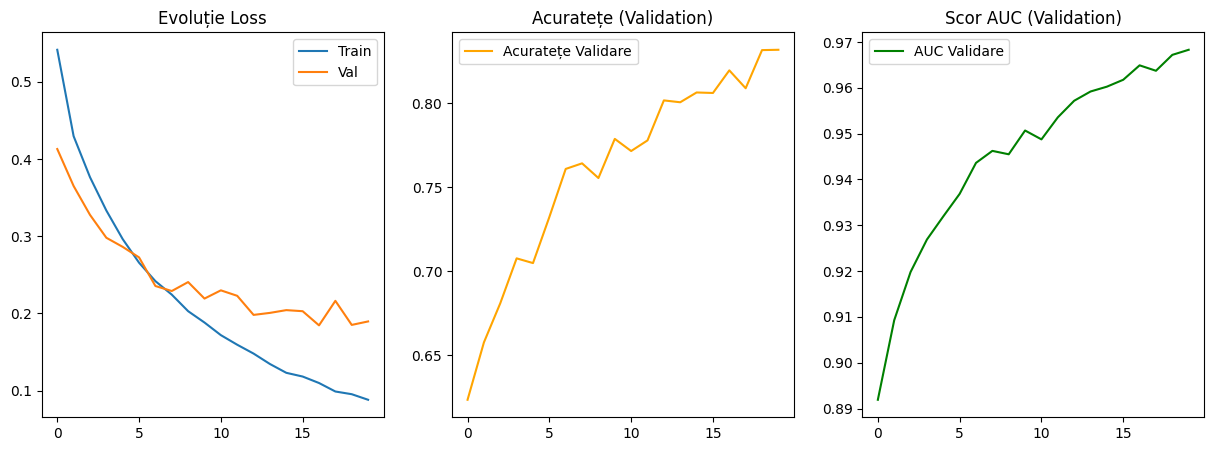

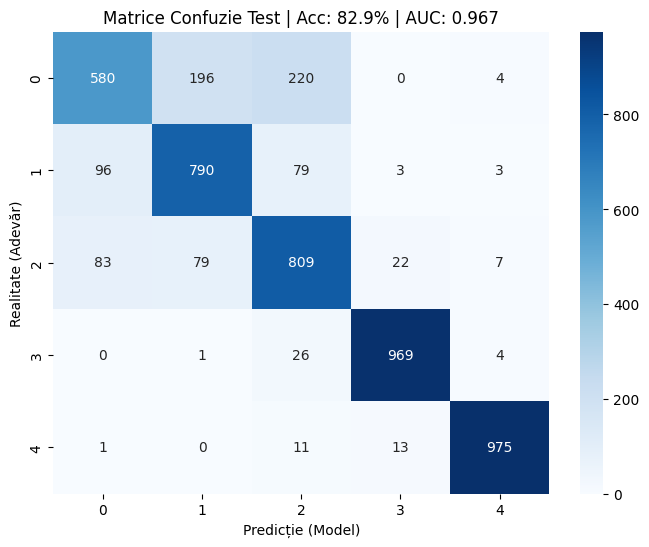

✅ Gata! Fisiere salvate cu formatul: resnet50_focal_loss_adam_LR_0.0001


In [ ]:
# 1. Resnet50 + focal_loss + Adam
%run Clasificare_datasets_balanced/train.py --model resnet50 --loss_name focal_loss --epochs 20 --batch_size 32 --num_workers 8

🔥 Config: resnet50 | Loss: focal_loss | Opt: adamw | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 0.5450 | V_Loss: 0.4324 | V_Acc: 59.7% | V_AUC: 0.8904 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 02/20 | T_Loss: 0.4272 | V_Loss: 0.3602 | V_Acc: 66.2% | V_AUC: 0.9086 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 03/20 | T_Loss: 0.3724 | V_Loss: 0.3309 | V_Acc: 68.5% | V_AUC: 0.9181 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 04/20 | T_Loss: 0.3277 | V_Loss: 0.3001 | V_Acc: 69.3% | V_AUC: 0.9277 🌟 NOU BEST
Durată Epocă: 5.95 min


...

Ep 17/20 | T_Loss: 0.1070 | V_Loss: 0.1915 | V_Acc: 82.1% | V_AUC: 0.9646 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 18/20 | T_Loss: 0.0950 | V_Loss: 0.1998 | V_Acc: 82.0% | V_AUC: 0.9659 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 19/20 | T_Loss: 0.0918 | V_Loss: 0.1858 | V_Acc: 82.3% | V_AUC: 0.9645 
Durată Epocă: 5.93 min


Ep 20/20 | T_Loss: 0.0850 | V_Loss: 0.1886 | V_Acc: 83.6% | V_AUC: 0.9683 🌟 NOU BEST
Durată Epocă: 5.95 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 83.44%
   ► Scor AUC:  0.9684
   ► Pierdere (Loss): 0.1853

📈 Generăm graficele...


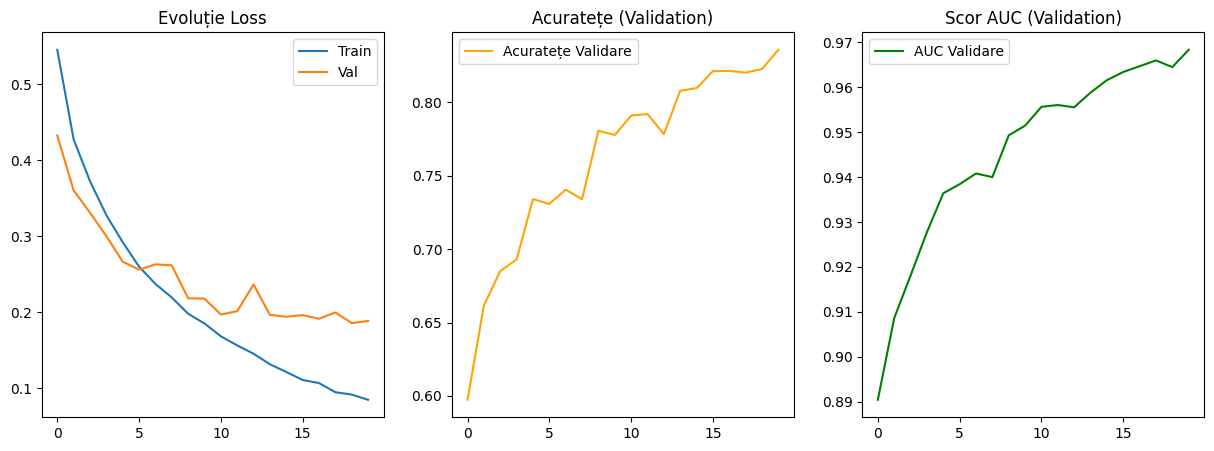

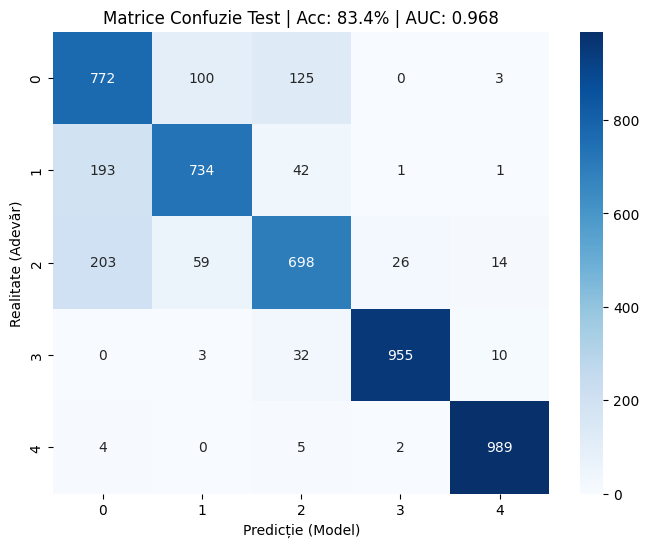

✅ Gata! Fisiere salvate cu formatul: resnet50_focal_loss_adamw_LR_0.0001


In [ ]:
# 2. Resnet50 + focal_loss + AdamW
%run Clasificare_datasets_balanced/train.py --model resnet50 --loss_name focal_loss --epochs 20 --batch_size 32 --num_workers 8 --lr 0.0001 --optimizer "adamw"

🔥 Config: resnet50 | Loss: ce | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 1.0460 | V_Loss: 0.8650 | V_Acc: 63.1% | V_AUC: 0.8974 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 02/20 | T_Loss: 0.8734 | V_Loss: 0.8267 | V_Acc: 65.2% | V_AUC: 0.9078 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 03/20 | T_Loss: 0.7781 | V_Loss: 0.7052 | V_Acc: 70.6% | V_AUC: 0.9247 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 04/20 | T_Loss: 0.6936 | V_Loss: 0.6310 | V_Acc: 73.7% | V_AUC: 0.9338 🌟 NOU BEST
Durată Epocă: 5.95 min


...

Ep 17/20 | T_Loss: 0.2143 | V_Loss: 0.4524 | V_Acc: 83.8% | V_AUC: 0.9703 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 18/20 | T_Loss: 0.2026 | V_Loss: 0.4273 | V_Acc: 84.0% | V_AUC: 0.9706 🌟 NOU BEST
Durată Epocă: 5.95 min


Ep 19/20 | T_Loss: 0.1879 | V_Loss: 0.4477 | V_Acc: 83.9% | V_AUC: 0.9713 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 20/20 | T_Loss: 0.1790 | V_Loss: 0.4384 | V_Acc: 85.0% | V_AUC: 0.9737 🌟 NOU BEST
Durată Epocă: 5.95 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 84.41%
   ► Scor AUC:  0.9734
   ► Pierdere (Loss): 0.4400

📈 Generăm graficele...


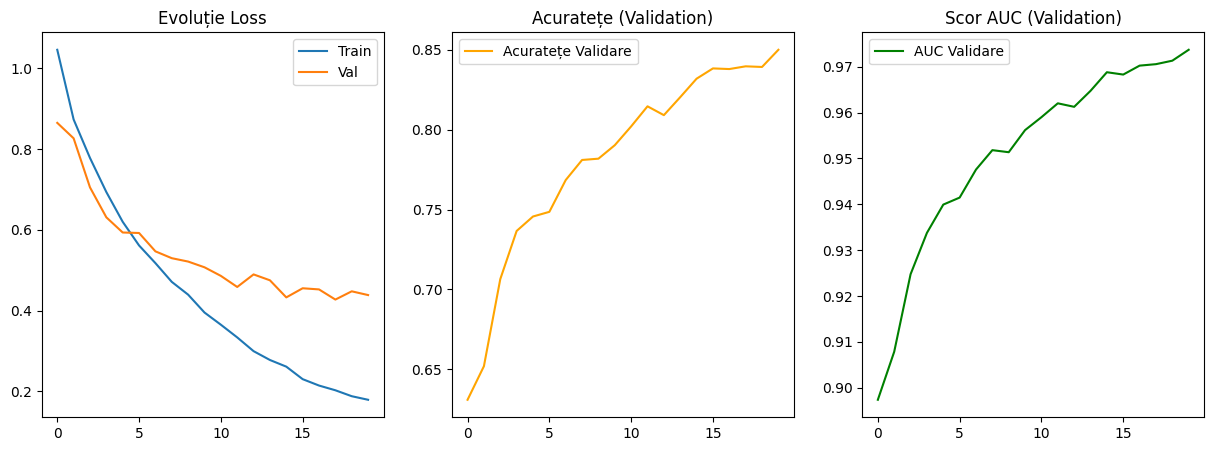

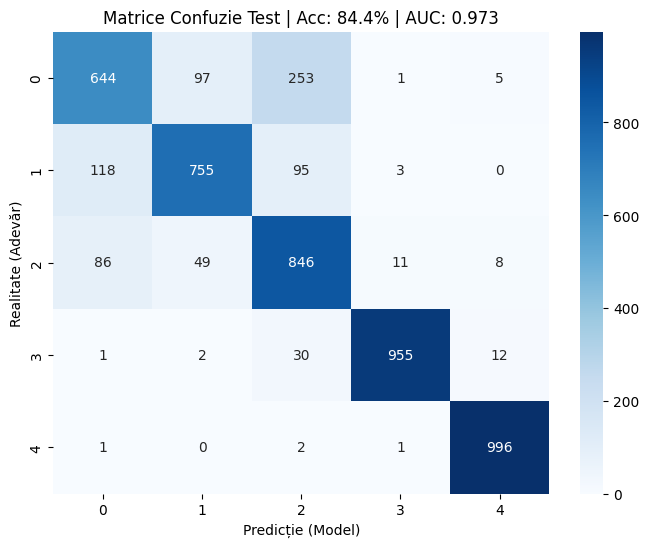

✅ Gata! Fisiere salvate cu formatul: resnet50_ce_adam_LR_0.0001


In [ ]:
# 3. Resnet50 + ce + Adam
%run Clasificare_datasets_balanced/train.py --model resnet50 --loss_name ce --epochs 20 --batch_size 32 --num_workers 8 --lr 0.0001

🔥 Config: resnet50 | Loss: weighted_ce | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 0.9771 | V_Loss: 0.9086 | V_Acc: 60.9% | V_AUC: 0.8925 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 02/20 | T_Loss: 0.7724 | V_Loss: 0.8037 | V_Acc: 66.0% | V_AUC: 0.9092 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 03/20 | T_Loss: 0.6619 | V_Loss: 0.7055 | V_Acc: 70.0% | V_AUC: 0.9227 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 04/20 | T_Loss: 0.5647 | V_Loss: 0.6628 | V_Acc: 70.9% | V_AUC: 0.9295 🌟 NOU BEST
Durată Epocă: 5.94 min


...

Ep 17/20 | T_Loss: 0.1877 | V_Loss: 0.4661 | V_Acc: 83.0% | V_AUC: 0.9666 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 18/20 | T_Loss: 0.1725 | V_Loss: 0.4826 | V_Acc: 83.0% | V_AUC: 0.9678 🌟 NOU BEST
Durată Epocă: 5.94 min


Ep 19/20 | T_Loss: 0.1628 | V_Loss: 0.4552 | V_Acc: 83.5% | V_AUC: 0.9686 🌟 NOU BEST
Durată Epocă: 5.93 min


Ep 20/20 | T_Loss: 0.1543 | V_Loss: 0.4165 | V_Acc: 84.6% | V_AUC: 0.9722 🌟 NOU BEST
Durată Epocă: 5.96 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 84.73%
   ► Scor AUC:  0.9730
   ► Pierdere (Loss): 0.4016

📈 Generăm graficele...


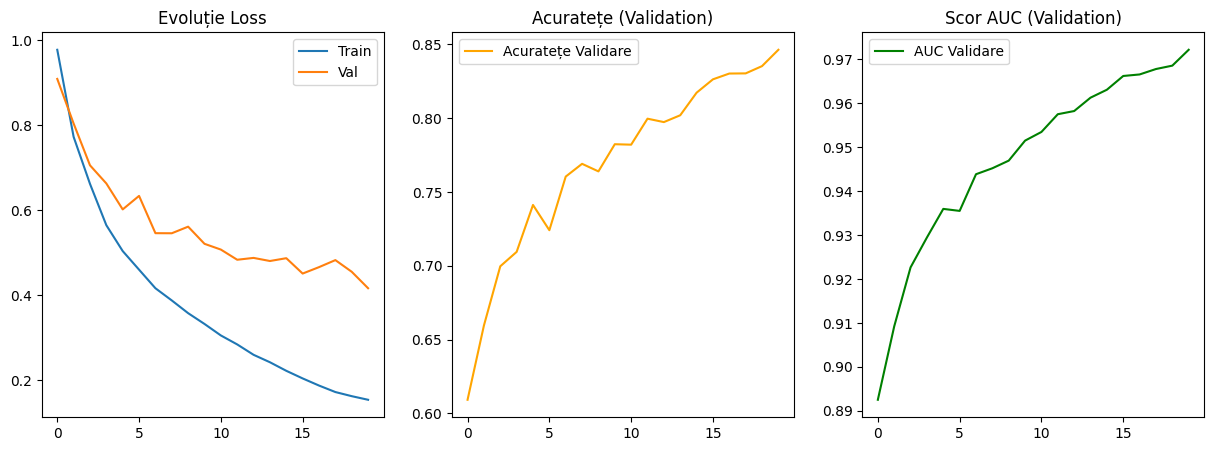

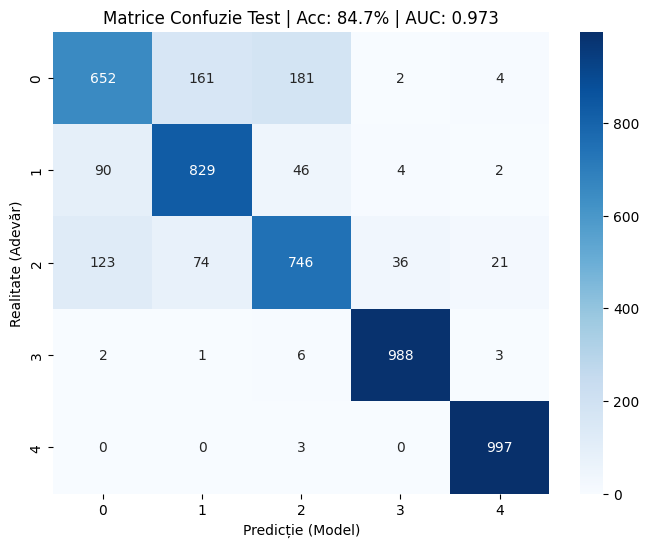

✅ Gata! Fisiere salvate cu formatul: resnet50_weighted_ce_adam_LR_0.0001


In [ ]:
# 4. Resnet50 + weighted_ce + AdamW
%run Clasificare_datasets_balanced/train.py --model resnet50 --loss_name weighted_ce --epochs 20 --batch_size 32 --num_workers 8 --lr 0.0001 --class_weights 1.0 1.2 1.5 2.0 3.0

🔥 Config: inception_v3 | Loss: focal_loss | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 0.4995 | V_Loss: 0.4329 | V_Acc: 60.5% | V_AUC: 0.8918 🌟 NOU BEST
Durată Epocă: 8.12 min


Ep 02/20 | T_Loss: 0.3944 | V_Loss: 0.3314 | V_Acc: 67.8% | V_AUC: 0.9178 🌟 NOU BEST
Durată Epocă: 8.14 min


Ep 03/20 | T_Loss: 0.3299 | V_Loss: 0.2994 | V_Acc: 70.5% | V_AUC: 0.9263 🌟 NOU BEST
Durată Epocă: 8.07 min


Ep 04/20 | T_Loss: 0.2862 | V_Loss: 0.2720 | V_Acc: 73.2% | V_AUC: 0.9375 🌟 NOU BEST
Durată Epocă: 8.13 min


...

Ep 17/20 | T_Loss: 0.0806 | V_Loss: 0.1660 | V_Acc: 85.2% | V_AUC: 0.9723 🌟 NOU BEST
Durată Epocă: 8.18 min


Ep 18/20 | T_Loss: 0.0735 | V_Loss: 0.1781 | V_Acc: 84.6% | V_AUC: 0.9718 
Durată Epocă: 8.32 min


Ep 19/20 | T_Loss: 0.0671 | V_Loss: 0.1755 | V_Acc: 85.5% | V_AUC: 0.9743 🌟 NOU BEST
Durată Epocă: 8.27 min


Ep 20/20 | T_Loss: 0.0658 | V_Loss: 0.1685 | V_Acc: 86.1% | V_AUC: 0.9760 🌟 NOU BEST
Durată Epocă: 8.21 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 86.04%
   ► Scor AUC:  0.9770
   ► Pierdere (Loss): 0.1607

📈 Generăm graficele...


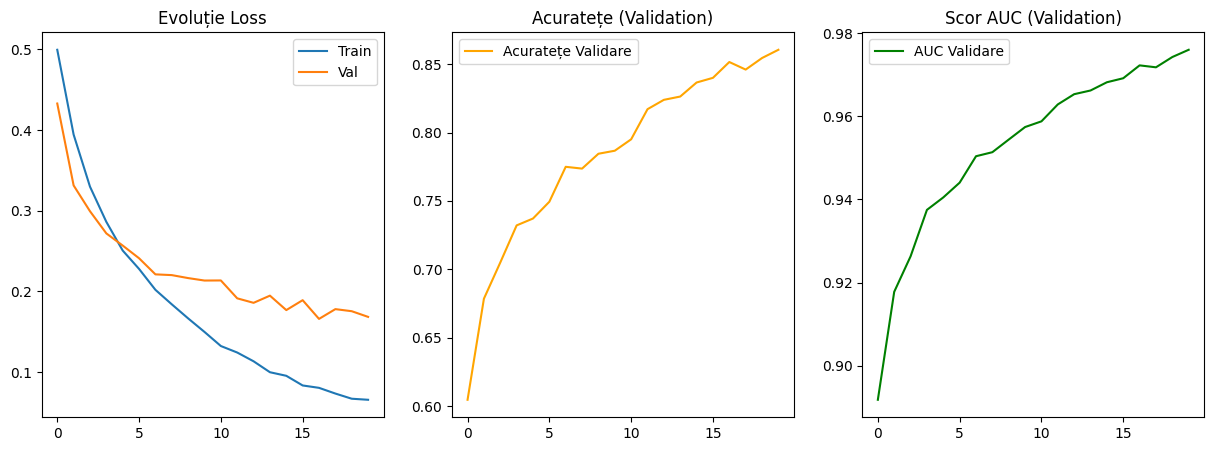

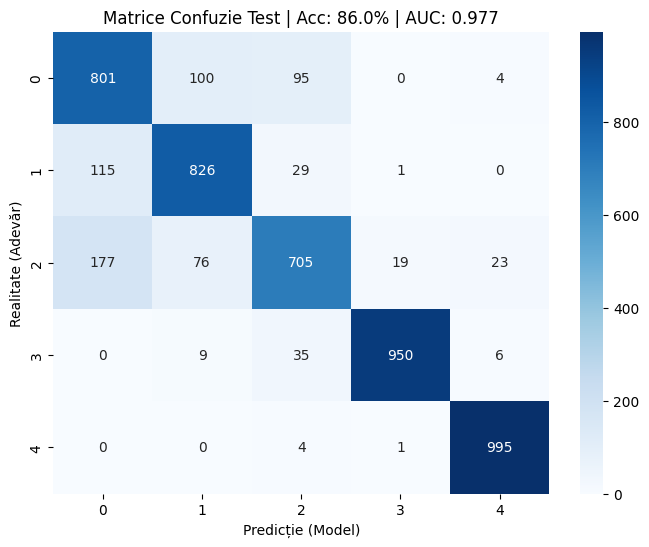

✅ Gata! Fisiere salvate cu formatul: inception_v3_focal_loss_adam_LR_0.0001


In [ ]:
# 5. InceptionV3 + focal_loss + Adam
%run Clasificare_datasets_balanced/train.py --model inception_v3 --loss_name focal_loss --epochs 20 --batch_size 32 --num_workers 8 --lr 0.0001 --img_size 299

🔥 Config: incres_v2 | Loss: focal_loss | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=34792 | VALIDARE=9940 | TESTARE=4971


Ep 01/20 | T_Loss: 0.4567 | V_Loss: 0.3978 | V_Acc: 64.5% | V_AUC: 0.9003 🌟 NOU BEST
Durată Epocă: 17.47 min


Ep 02/20 | T_Loss: 0.3393 | V_Loss: 0.3247 | V_Acc: 69.5% | V_AUC: 0.9235 🌟 NOU BEST
Durată Epocă: 17.01 min


Ep 03/20 | T_Loss: 0.2745 | V_Loss: 0.2738 | V_Acc: 72.0% | V_AUC: 0.9371 🌟 NOU BEST
Durată Epocă: 16.55 min


Ep 04/20 | T_Loss: 0.2319 | V_Loss: 0.2383 | V_Acc: 75.4% | V_AUC: 0.9451 🌟 NOU BEST
Durată Epocă: 16.38 min


...

Ep 17/20 | T_Loss: 0.0506 | V_Loss: 0.1894 | V_Acc: 85.5% | V_AUC: 0.9762 🌟 NOU BEST
Durată Epocă: 15.91 min


Ep 18/20 | T_Loss: 0.0450 | V_Loss: 0.1703 | V_Acc: 86.7% | V_AUC: 0.9773 🌟 NOU BEST
Durată Epocă: 15.79 min


Ep 19/20 | T_Loss: 0.0418 | V_Loss: 0.2132 | V_Acc: 84.7% | V_AUC: 0.9762 
Durată Epocă: 15.69 min


Ep 20/20 | T_Loss: 0.0422 | V_Loss: 0.1884 | V_Acc: 85.8% | V_AUC: 0.9767 
Durată Epocă: 17.32 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 86.52%
   ► Scor AUC:  0.9761
   ► Pierdere (Loss): 0.1786

📈 Generăm graficele...


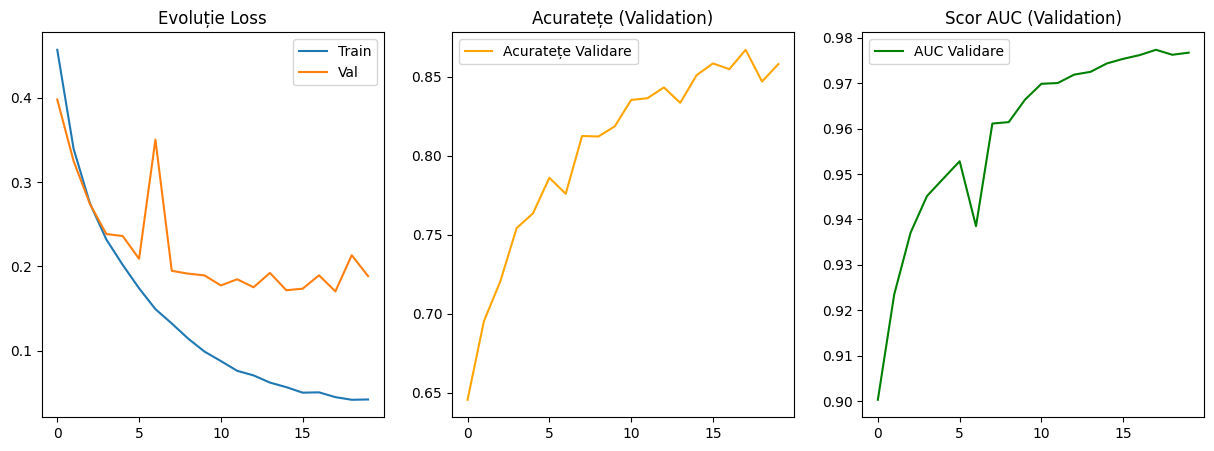

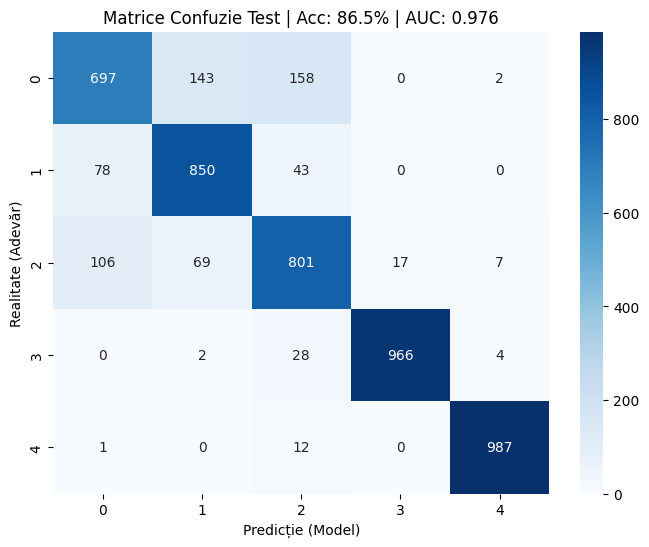

✅ Gata! Fisiere salvate cu formatul: incres_v2_focal_loss_adam_LR_0.0001


In [ ]:
# 6. InceptionResNetV2 + focal_loss + AdamW
%run Clasificare_datasets_balanced/train.py --model incres_v2 --loss_name focal_loss --epochs 20 --batch_size 32 --num_workers 8 --lr 0.0001 --img_size 299

## Part 2 (Dataset concatenat)


🔥 Config: resnet50 | Loss: focal_loss | Opt: adam | LR: 0.0001
📊 Distribuție Date: TRAIN=42292 | VALIDARE=10940 | TESTARE=6221


Ep 01/20 | T_Loss: 0.6130 | V_Loss: 0.4935 | V_Acc: 62.8% | V_AUC: 0.8990 🌟 NOU BEST
Durată Epocă: 8.34 min


Ep 02/20 | T_Loss: 0.4806 | V_Loss: 0.4511 | V_Acc: 64.5% | V_AUC: 0.9133 🌟 NOU BEST
Durată Epocă: 6.90 min


Ep 03/20 | T_Loss: 0.4118 | V_Loss: 0.3997 | V_Acc: 69.6% | V_AUC: 0.9237 🌟 NOU BEST
Durată Epocă: 6.58 min


Ep 04/20 | T_Loss: 0.3623 | V_Loss: 0.3869 | V_Acc: 71.2% | V_AUC: 0.9301 🌟 NOU BEST
Durată Epocă: 9.20 min


...

Ep 17/20 | T_Loss: 0.1362 | V_Loss: 0.3092 | V_Acc: 80.4% | V_AUC: 0.9582 
Durată Epocă: 11.33 min


Ep 18/20 | T_Loss: 0.1263 | V_Loss: 0.3040 | V_Acc: 80.5% | V_AUC: 0.9596 🌟 NOU BEST
Durată Epocă: 25.09 min


Ep 19/20 | T_Loss: 0.1186 | V_Loss: 0.3015 | V_Acc: 81.5% | V_AUC: 0.9624 🌟 NOU BEST
Durată Epocă: 12.15 min


Ep 20/20 | T_Loss: 0.1115 | V_Loss: 0.3289 | V_Acc: 79.7% | V_AUC: 0.9614 
Durată Epocă: 7.26 min

🚀 START FAZA DE TESTARE FINALĂ (PE FOLDERUL 'TEST')


📊 REZULTATE TESTARE FINALĂ:
   ► Acuratețe: 78.30%
   ► Scor AUC:  0.9537
   ► Pierdere (Loss): 0.3918

📈 Generăm graficele...


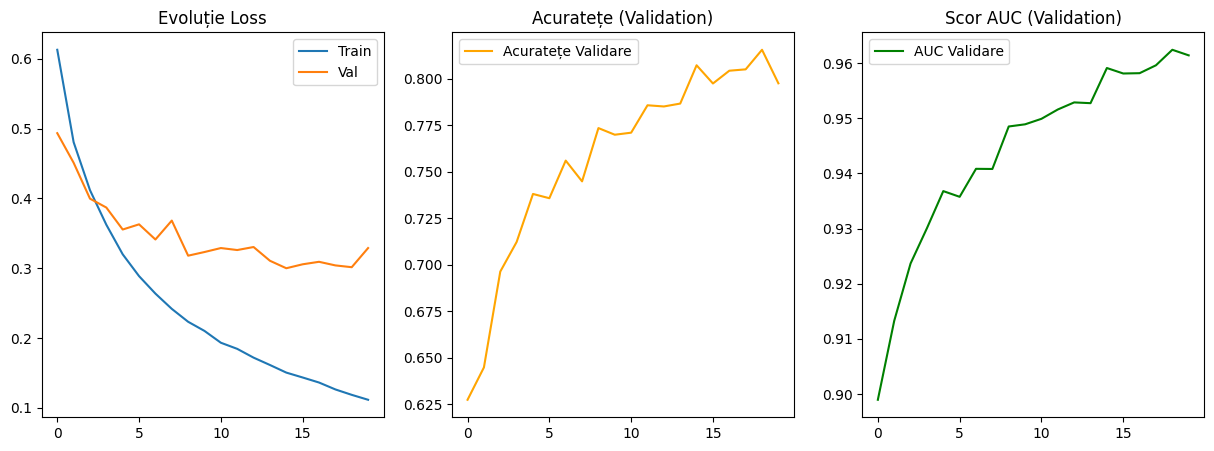

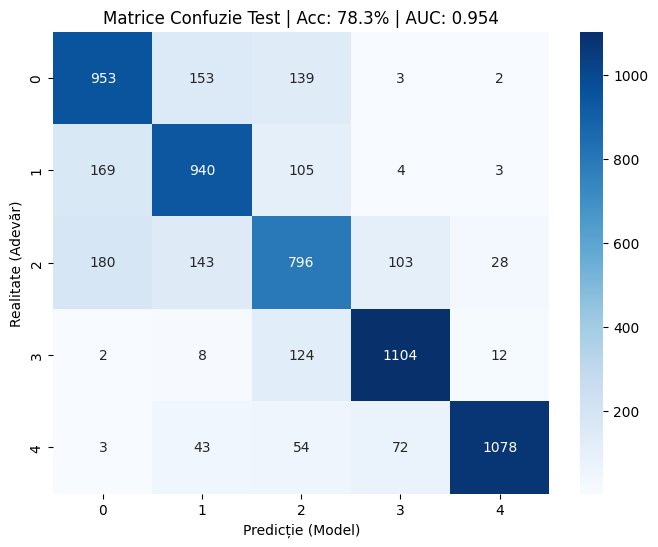

✅ Gata! Fisiere salvate cu formatul: resnet50_focal_loss_adam_LR_0.0001


In [1]:
# 1. Resnet50 + focal_loss + Adam
%run Clasificare_datasets_balanced/train.py --model resnet50 --loss_name focal_loss --epochs 20 --batch_size 32 --num_workers 8 --root_dir "../datasets/dataset_combinat"

In [ ]:
# Concatenate balanced dataset with aptops_ben_graham and see if better results                     X
# Make site for inference and deploy model on it + recommendations for patients/medical staff       X